[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/arvidl/BMED365-2026/blob/main/Lab5-Comp-Mod/notebooks/05-cell-signaling.ipynb)

# 05 — Cell Signaling and Gene Regulatory Networks
## Computational Modeling of Cellular Decision-Making

Arvid Lundervold w/Claude 3.5 Sonnet, Grok 3, and Claude Opus 4 — 2025-02-23 <br>
_Updated: 2026-02-19_  (Cursor 2.5.17 with Claude Opus 4.6)

---

## 1. Motivation & Learning Objectives

### Why study cell signaling and gene regulatory networks?

Every living cell is a remarkably sophisticated **information-processing system**. From the moment a hormone binds a receptor on a cell's surface, through cascades of molecular interactions, to the final decision to divide, differentiate, or die — **cell signaling** orchestrates the entire life of a cell.

**Gene regulatory networks (GRNs)** are the computational circuits of the cell. They integrate signals, make decisions, and control gene expression — determining which proteins are made, when, and in what quantities. Understanding these networks is fundamental to:

- 🧬 **Decoding how cells make decisions** — how does a stem cell "decide" to become a neuron vs. a muscle cell?
- 🦠 **Understanding disease** — cancer, diabetes, autoimmune disorders, and neurodegenerative diseases all involve signaling dysfunction
- 💊 **Designing targeted therapies** — most modern drugs work by modulating specific signaling pathways
- 🧪 **Engineering biology** — synthetic biology reprograms cellular circuits to create living therapeutics, biosensors, and more
- 🤖 **Bridging biology and computation** — cells perform computation with molecular networks, inspiring new models of information processing

### Learning objectives

After working through this notebook, you will be able to:

1. **Define** the key concepts in cell signaling: ligands, receptors, signal transduction, gene regulation, feedback loops, and homeostasis
2. **Explain** the historical milestones that shaped our understanding of cellular communication
3. **Formulate** mathematical models of gene expression, feedback regulation, and signaling cascades using ODEs
4. **Implement** deterministic and stochastic simulations of signaling networks in Python
5. **Analyze** network motifs (feedforward loops, toggle switches, oscillators) and their functional roles
6. **Explore** clinical and scientific implications — from cancer therapy to synthetic biology to systems medicine



---

## 2. Key Definitions

Before diving in, let us establish the core vocabulary of cell signaling and gene regulation:

| Term | Definition |
|------|-----------|
| **Cell signaling** | The process by which cells detect, transmit, and respond to information from their environment and from other cells, using molecular messengers and intracellular cascades |
| **Ligand** | A molecule (hormone, neurotransmitter, growth factor, cytokine) that binds to a specific receptor to initiate a signaling event |
| **Receptor** | A protein (often membrane-bound) that specifically recognizes and binds a ligand, triggering an intracellular response |
| **Signal transduction** | The chain of molecular events by which an extracellular signal is converted into an intracellular response — often involving kinase cascades, second messengers, and transcription factor activation |
| **Second messenger** | Small intracellular molecules (e.g., cAMP, Ca²⁺, IP₃) that relay and amplify signals from receptors to effector proteins |
| **Gene expression** | The process by which information encoded in DNA is transcribed into mRNA and then translated into functional proteins |
| **Transcription factor (TF)** | A protein that binds specific DNA sequences to activate or repress the transcription of target genes |
| **Gene regulatory network (GRN)** | A collection of genes, transcription factors, and regulatory elements that interact to control gene expression patterns — the "wiring diagram" of cellular decision-making |
| **Feedback loop** | A circuit motif where a downstream product influences its own upstream regulation — **negative feedback** stabilizes; **positive feedback** amplifies and can create bistability |
| **Homeostasis** | The ability of a cell or organism to maintain stable internal conditions (e.g., temperature, pH, protein concentrations) despite external perturbations — often achieved through negative feedback |
| **Network motif** | A recurring, statistically significant sub-pattern in a regulatory network (e.g., feedforward loop, toggle switch, oscillator) that performs a specific information-processing function |
| **Bistability** | The ability of a system to exist in one of two stable steady states — a hallmark of cellular decision-making, where cells commit to one fate or another |
| **Stochastic gene expression** | The inherent randomness in gene expression arising from the discrete nature of molecular events (transcription, translation) — especially important when molecule numbers are low |

---

## 3. Historical Context: Decoding the Language of Cells

The study of cell signaling and gene regulation is one of the great intellectual achievements of 20th and 21st century biology. Here are some key milestones:

### The discovery of hormones and chemical signaling (1900s–1940s)

- **1902**: William Bayliss and Ernest Starling discovered **secretin** — the first hormone — showing that the gut communicates with the pancreas via a chemical messenger in the blood, not via nerves. Starling coined the term *hormone* (from Greek *hormōn*, "to set in motion") in 1905.
- **1905–1920s**: The concept of **chemical neurotransmission** emerged. Otto Loewi's elegant 1921 experiment — transferring fluid from a stimulated frog heart to a resting one — proved that nerves release chemical substances (**acetylcholine**), earning him the 1936 Nobel Prize in Physiology or Medicine (shared with Henry Dale).
- **1940s–1950s**: Earl Sutherland discovered **cyclic AMP (cAMP)** as a "second messenger" — a molecule that relays the hormonal signal inside the cell. This revealed that hormones don't enter cells; they activate intracellular signaling cascades. Nobel Prize 1971.

### The genetic switch: gene regulation is discovered (1960s)

- **1961**: François Jacob and Jacques Monod published their landmark paper describing the **lac operon** in *E. coli* — the first gene regulatory network. They showed that genes are not always "on"; instead, **repressor proteins** bind DNA to switch genes off, and signals (like lactose) can relieve repression. This was the birth of **molecular systems biology**. Nobel Prize 1965.
- Their work introduced key concepts: **operators**, **promoters**, **inducers**, and **regulatory genes** — the vocabulary we still use today.

### Signal transduction cascades (1970s–1990s)

- **1970s–1980s**: Martin Rodbell and Alfred Gilman elucidated the role of **G-proteins** as molecular switches that relay signals from membrane receptors to intracellular effectors. Nobel Prize 1994.
- **1980s–1990s**: The discovery of **receptor tyrosine kinases (RTKs)**, **MAP kinase cascades**, and the **Ras/Raf/MEK/ERK pathway** — the central highway of growth factor signaling. Mutations in **Ras** were found in ~30% of human cancers.
- **1992**: Edwin Krebs and Edmond Fischer received the Nobel Prize for discovering **reversible protein phosphorylation** — the universal language of signal transduction.

### Gene regulatory networks and systems biology (1990s–present)

- **1995**: Stuart Kauffman's work on **Boolean network models** of gene regulation introduced the idea that cells are computational devices, with GRNs as their "programs."
- **2000**: The landmark paper by Tim Gardner, Charles Cantor, and James Collins demonstrated a synthetic **genetic toggle switch** in *E. coli* — a two-gene circuit that could be flipped between two stable states. This proved that gene circuits follow principles of **engineering design** and launched the field of **synthetic biology**.
- **2000**: Michael Elowitz and Stanislas Leibler built the **Repressilator** — a synthetic three-gene oscillator in *E. coli* that produces periodic fluctuations, like an intracellular clock.
- **2002**: Uri Alon and colleagues discovered that gene regulatory networks are built from a small set of recurring **network motifs** — feedforward loops, feedback loops, and cascades — each performing a specific computational function. This was a foundational insight for systems biology.
- **2007–2012**: Shinya Yamanaka's discovery of **induced pluripotent stem cells (iPSCs)** demonstrated that a handful of transcription factors (Oct4, Sox2, Klf4, c-Myc) can reprogram the entire gene regulatory network of a differentiated cell, resetting it to a stem-cell-like state. Nobel Prize 2012 (shared with John Gurdon).

### The age of single-cell and spatial biology (2010s–present)

- **2010s–2020s**: Single-cell RNA sequencing (scRNA-seq) has revealed that **gene expression is inherently noisy** — even genetically identical cells in the same environment show enormous variability in which genes they express. This "noise" is not a bug; it's a feature that enables **bet-hedging**, **cell-fate decisions**, and **population heterogeneity**.
- Spatial transcriptomics technologies now allow us to see where genes are expressed within tissues, connecting molecular signaling to tissue architecture.

---

## 4. Scientific and Clinical Implications

Understanding cell signaling and gene regulatory networks has transformed both fundamental biology and clinical medicine:

### Cancer biology & targeted therapy

Cancer is fundamentally a **disease of cell signaling gone wrong**. Oncogenic mutations hijack signaling pathways, causing uncontrolled growth, evasion of cell death, and metastasis.

- **Imatinib (Gleevec)**: A revolutionary drug that targets the BCR-ABL kinase in chronic myeloid leukemia (CML) — one of the first examples of a **molecularly targeted therapy**. By inhibiting a single aberrant signaling node, it converted CML from a death sentence to a manageable chronic disease.
- **BRAF inhibitors** (vemurafenib, dabrafenib): Target mutant BRAF (V600E) in melanoma, blocking the overactive MAPK signaling cascade.
- **Immune checkpoint inhibitors**: Drugs like pembrolizumab block the PD-1/PD-L1 signaling axis, unleashing the immune system against cancer. Nobel Prize 2018 (James Allison & Tasuku Honjo).
- Systems-level analysis of **GRNs in tumors** is revealing drug resistance mechanisms and guiding combination therapies.

### Developmental biology & regenerative medicine

Gene regulatory networks orchestrate **embryonic development** — the transformation of a single fertilized egg into a complex organism with hundreds of cell types.

- **Morphogen gradients** (e.g., Sonic Hedgehog, Wnt, BMP) form spatial signaling patterns that tell cells their position and fate
- GRNs underlie **cell fate decisions**: the commitment of a progenitor cell to become, say, a neuron vs. an astrocyte
- Understanding these networks enables **cellular reprogramming** (iPSC technology) and may ultimately allow us to grow replacement organs

### Metabolic & endocrine disorders

- **Diabetes**: Type 2 diabetes involves insulin resistance — cells fail to respond properly to the insulin signaling pathway (Insulin → Insulin Receptor → IRS → PI3K → Akt → GLUT4 translocation)
- **Thyroid disorders**: The hypothalamic-pituitary-thyroid axis is a classic negative feedback loop; understanding it explains Graves' disease (overactive) and Hashimoto's thyroiditis (underactive)
- **Homeostasis** in metabolic networks is maintained through multiple interlocking feedback loops

### Neuroscience

- Synaptic signaling (neurotransmitter release → receptor binding → postsynaptic cascades) is the basis of all brain function
- Long-term memory requires signaling cascades (CREB pathway) that activate gene expression
- Neurodegenerative diseases (Alzheimer's, Parkinson's) involve disrupted signaling and protein homeostasis

### Synthetic biology & biotechnology

- Engineered **gene circuits** (toggle switches, oscillators, logic gates) are being used to build:
  - Living therapeutics (engineered bacteria that sense tumors and release drugs)
  - Biosensors (cells that detect pollutants or pathogens)
  - Metabolic engineering (cells reprogrammed to produce biofuels or pharmaceuticals)
- The design principles come directly from understanding natural signaling networks

### Computational modeling as a clinical tool

- **Digital twin** models of patient-specific signaling networks are being developed to predict individual drug responses
- Network-based drug discovery identifies new drug targets by analyzing the topology of signaling networks
- Computational models of GRNs help predict cell fate in response to perturbations (gene knockouts, drug treatments)

---

## 5. Conceptual and Mathematical Framework

### Overview of the modeling pipeline

This notebook covers several levels of modeling, from gene expression to network dynamics:

| Level | What we model | Mathematical tool | Python tool |
|-------|--------------|-------------------|-------------|
| Gene expression | mRNA and protein dynamics | Coupled ODEs | `scipy.integrate.odeint` |
| Stochastic gene expression | Random fluctuations in molecule numbers | Gillespie's SSA (stochastic simulation algorithm) | Custom implementation |
| Feedback regulation | Negative/positive feedback loops | Hill-function ODEs | `scipy.integrate.odeint` |
| Network topology | Regulatory interactions between genes | Graph theory | `networkx` |
| Spatial signaling | Diffusion + reaction in space | Reaction-diffusion PDEs | `numpy` + finite differences |
| Cell-cell communication | Paracrine/juxtacrine signaling | Coupled multi-cell ODEs | `scipy.integrate.odeint` |
| Drug intervention | Pharmacological perturbation of pathways | Modified ODEs | `scipy.integrate.odeint` |
| Network motifs | Functional circuit elements (FFL, toggle switch) | Graph analysis + ODE simulation | `networkx` + `scipy` |

### The Central Dogma as a dynamical system

The simplest model of gene expression describes the two-step process:
$$\text{DNA} \xrightarrow{k_{\text{trans}}} \text{mRNA} \xrightarrow{k_{\text{transl}}} \text{Protein}$$

As a system of ODEs:

$$\frac{d[\text{mRNA}]}{dt} = k_{\text{trans}} - \gamma_{\text{mRNA}}[\text{mRNA}]$$

$$\frac{d[\text{Protein}]}{dt} = k_{\text{transl}}[\text{mRNA}] - \gamma_{\text{protein}}[\text{Protein}]$$

where $k_{\text{trans}}$ is the transcription rate, $k_{\text{transl}}$ is the translation rate, and $\gamma$ values are degradation rates.

### Feedback regulation and the Hill function

In real cells, gene expression is regulated. A transcription factor can **activate** or **repress** a gene. The **Hill function** captures this cooperative binding:

- **Activation**: $f([TF]) = \frac{[TF]^n}{K^n + [TF]^n}$ (sigmoidal increase)
- **Repression**: $f([TF]) = \frac{K^n}{K^n + [TF]^n}$ (sigmoidal decrease)

where $K$ is the half-maximal concentration and $n$ is the **Hill coefficient** (cooperativity).

For example, a gene repressed by its own protein product (negative autoregulation):

$$\frac{d[P]}{dt} = \frac{k}{1 + ([P]/K)^n} - \gamma [P]$$

### Stochastic effects

When molecule counts are low (as they often are for transcription factors — sometimes just a few copies per cell!), the continuous ODE description breaks down. The **Gillespie algorithm** (or stochastic simulation algorithm, SSA) provides an exact stochastic simulation by:
1. Computing reaction propensities (probabilities per unit time)
2. Drawing the time to the next reaction from an exponential distribution
3. Choosing which reaction occurs with probability proportional to its propensity
4. Updating molecule counts and repeating

This captures phenomena like **bursting** (genes switch between "on" and "off" states, producing intermittent mRNA bursts) and **cell-to-cell variability**.

---

## Table of Contents — Implementation Sections

The remainder of this notebook implements and explores these concepts through Python simulations:

1. [Gene Expression Dynamics (ODE Model)](#1-mathematical-introduction-to-gene-expression-dynamics)
2. [Gillespie's Stochastic Simulation Algorithm](#2-mathematical-introduction-to-gillespies-stochastic-simulation-algorithm-ssa)
3. [Gene Regulatory Network Visualization](#3-mathematical-introduction-to-gene-regulatory-networks)
4. [Parameter Sensitivity Analysis](#4-mathematical-introduction-to-parameter-sensitivity-analysis-in-gene-expression)
5. [Spatial Gene Expression Modeling](#5-mathematical-introduction-to-spatial-gene-expression-modeling)
6. [Interactive Gene Expression Simulator](#6-interactive-gene-expression-simulator)
7. [Cell-Cell Communication Modeling](#7-mathematical-introduction-to-cell-cell-communication-in-gene-expression)
8. [Drug Intervention Modeling](#9-mathematical-introduction-to-drug-intervention-in-gene-expression)
9. [Network Motifs](#10-mathematical-introduction-to-gene-regulatory-networks)
10. [Complex Gene Regulatory Network Analysis](#complex-gene-regulatory-network-analysis)

Key Python libraries used:
- **NumPy/SciPy** for numerical computations and ODE solving
- **Matplotlib/Plotly** for visualization
- **NetworkX** for network analysis and graph theory
- **Pandas** for data management
- **Dash** for interactive web-based exploration

In [ ]:
# --- Colab setup ---
import sys
if 'google.colab' in sys.modules:
    %pip install -q ipywidgets
    %matplotlib inline
else:
    %matplotlib inline

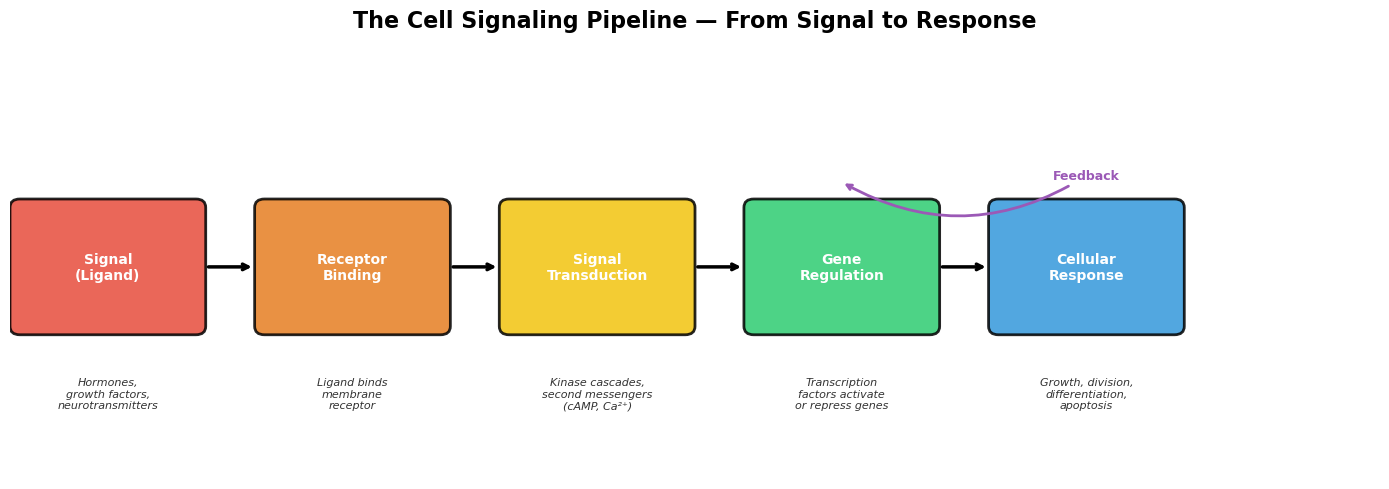

/var/folders/1g/_4x26lps6mgg1tr73d7g2bmh0000gp/T/ipykernel_28904/1361468852.py:125: UserWarning:

Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) DejaVu Sans.



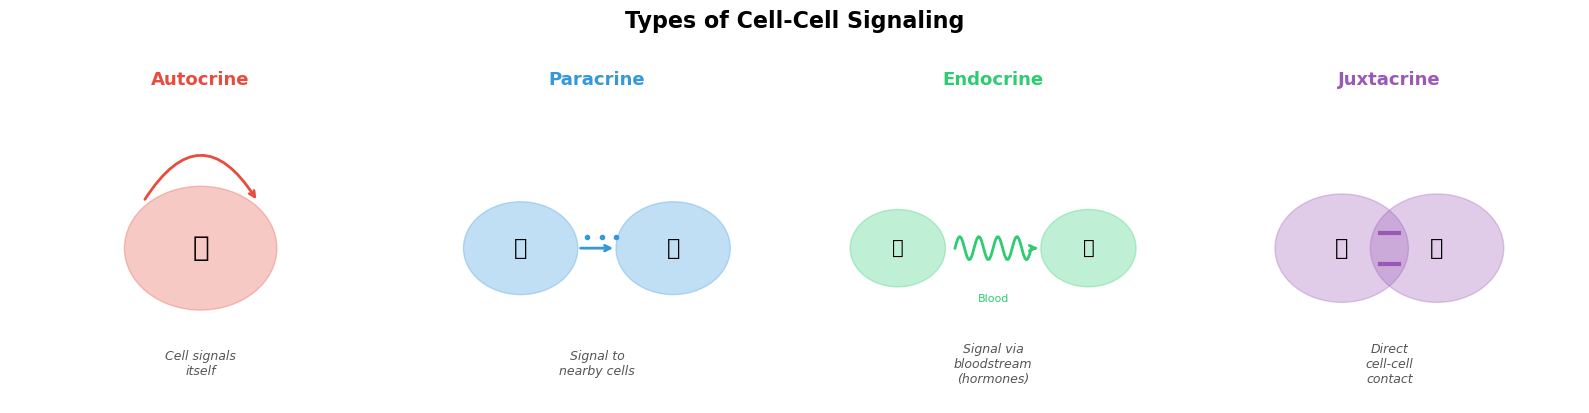

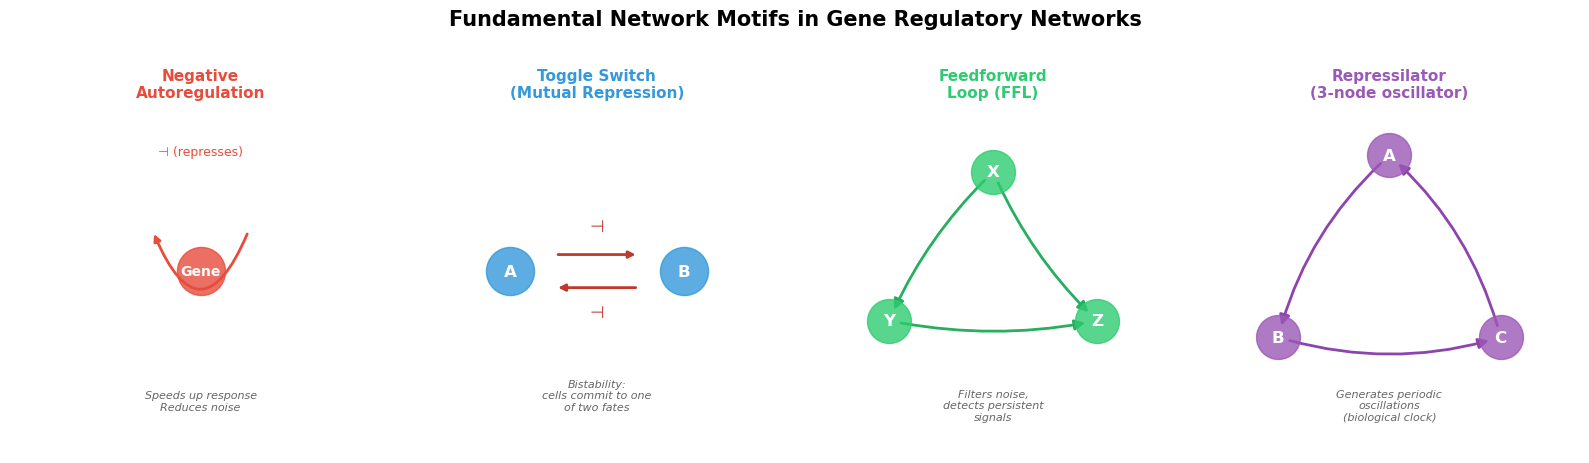

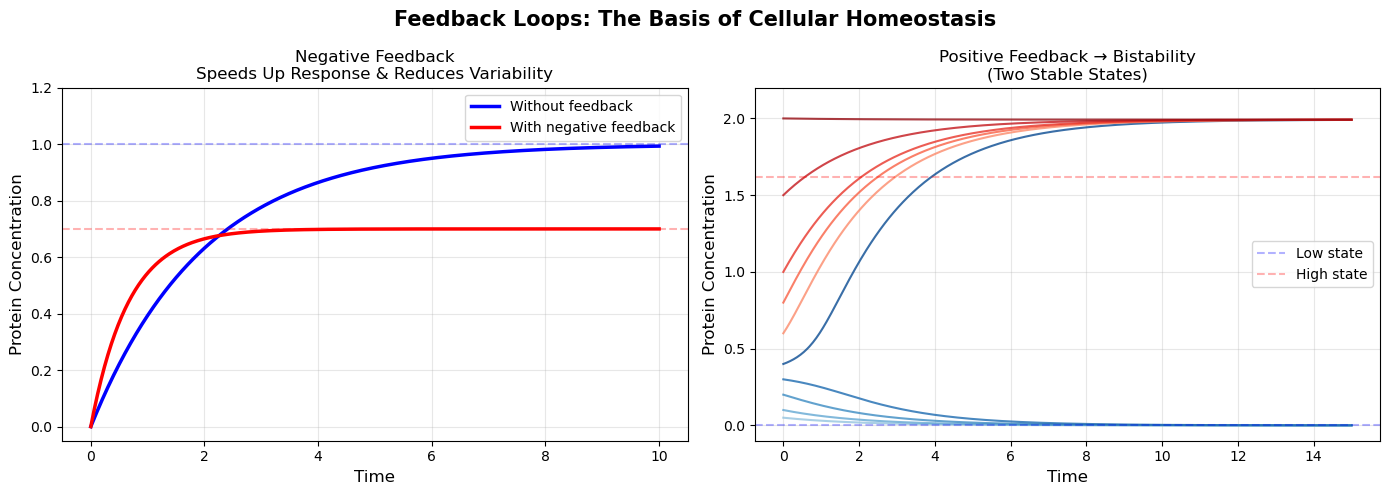

✓ Instructive diagrams generated successfully.


In [29]:
"""
Instructive Diagrams: Visual Overview of Cell Signaling & Gene Regulation
=========================================================================
These diagrams provide intuition for the key concepts before we dive into
the mathematical models and simulations.
"""
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import numpy as np
np.random.seed(42)

# ──────────────────────────────────────────────────────────────────────────────
# FIGURE 1: The Cell Signaling Pipeline
# ──────────────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(1, 1, figsize=(14, 5))
ax.set_xlim(0, 14)
ax.set_ylim(0, 5)
ax.axis('off')
ax.set_title('The Cell Signaling Pipeline — From Signal to Response',
             fontsize=16, fontweight='bold', pad=20)

# Define pipeline stages
stages = [
    (1.0, 2.5, 'Signal\n(Ligand)', '#E74C3C', 'Hormones,\ngrowth factors,\nneurotransmitters'),
    (3.5, 2.5, 'Receptor\nBinding', '#E67E22', 'Ligand binds\nmembrane\nreceptor'),
    (6.0, 2.5, 'Signal\nTransduction', '#F1C40F', 'Kinase cascades,\nsecond messengers\n(cAMP, Ca²⁺)'),
    (8.5, 2.5, 'Gene\nRegulation', '#2ECC71', 'Transcription\nfactors activate\nor repress genes'),
    (11.0, 2.5, 'Cellular\nResponse', '#3498DB', 'Growth, division,\ndifferentiation,\napoptosis'),
]

for x, y, label, color, desc in stages:
    # Main box
    box = mpatches.FancyBboxPatch((x - 0.9, y - 0.7), 1.8, 1.4,
                                   boxstyle="round,pad=0.1",
                                   facecolor=color, edgecolor='black',
                                   linewidth=2, alpha=0.85)
    ax.add_patch(box)
    ax.text(x, y, label, ha='center', va='center', fontsize=10,
            fontweight='bold', color='white')
    # Description below
    ax.text(x, y - 1.3, desc, ha='center', va='top', fontsize=8,
            color='#333333', style='italic')

# Arrows between stages
for i in range(len(stages) - 1):
    ax.annotate('', xy=(stages[i+1][0] - 1.0, stages[i+1][1]),
                xytext=(stages[i][0] + 1.0, stages[i][1]),
                arrowprops=dict(arrowstyle='->', color='black', lw=2.5))

# Feedback arrow (from response back to regulation)
ax.annotate('Feedback', xy=(8.5, 3.5), xytext=(11.0, 3.5),
            arrowprops=dict(arrowstyle='->', color='#9B59B6', lw=2,
                           connectionstyle='arc3,rad=-0.3'),
            fontsize=9, color='#9B59B6', fontweight='bold',
            ha='center', va='bottom')

plt.tight_layout()
plt.show()

# ──────────────────────────────────────────────────────────────────────────────
# FIGURE 2: Types of Signaling
# ──────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle('Types of Cell-Cell Signaling', fontsize=16, fontweight='bold', y=1.02)

signaling_types = [
    ('Autocrine', 'Cell signals\nitself', '#E74C3C'),
    ('Paracrine', 'Signal to\nnearby cells', '#3498DB'),
    ('Endocrine', 'Signal via\nbloodstream\n(hormones)', '#2ECC71'),
    ('Juxtacrine', 'Direct\ncell-cell\ncontact', '#9B59B6'),
]

for ax, (name, desc, color) in zip(axes, signaling_types):
    ax.set_xlim(0, 4)
    ax.set_ylim(0, 4)
    ax.axis('off')
    ax.set_title(name, fontsize=13, fontweight='bold', color=color)

    if name == 'Autocrine':
        cell = plt.Circle((2, 2), 0.8, color=color, alpha=0.3)
        ax.add_patch(cell)
        ax.text(2, 2, '🔵', ha='center', va='center', fontsize=20)
        ax.annotate('', xy=(2.6, 2.6), xytext=(1.4, 2.6),
                    arrowprops=dict(arrowstyle='->', color=color, lw=2,
                                   connectionstyle='arc3,rad=-0.8'))
    elif name == 'Paracrine':
        c1 = plt.Circle((1.2, 2), 0.6, color=color, alpha=0.3)
        c2 = plt.Circle((2.8, 2), 0.6, color=color, alpha=0.3)
        ax.add_patch(c1)
        ax.add_patch(c2)
        ax.text(1.2, 2, '🔵', ha='center', va='center', fontsize=16)
        ax.text(2.8, 2, '🔵', ha='center', va='center', fontsize=16)
        ax.annotate('', xy=(2.2, 2), xytext=(1.8, 2),
                    arrowprops=dict(arrowstyle='->', color=color, lw=2))
        # Small dots for diffusing signal
        for dx in [0.0, 0.15, 0.3]:
            ax.plot(1.9 + dx, 2.15, 'o', color=color, markersize=3)
    elif name == 'Endocrine':
        c1 = plt.Circle((1.0, 2), 0.5, color=color, alpha=0.3)
        c2 = plt.Circle((3.0, 2), 0.5, color=color, alpha=0.3)
        ax.add_patch(c1)
        ax.add_patch(c2)
        ax.text(1.0, 2, '🔵', ha='center', va='center', fontsize=14)
        ax.text(3.0, 2, '🔵', ha='center', va='center', fontsize=14)
        # Wavy line for bloodstream
        x_wave = np.linspace(1.6, 2.4, 50)
        y_wave = 2 + 0.15 * np.sin(8 * np.pi * (x_wave - 1.6) / 0.8)
        ax.plot(x_wave, y_wave, color=color, lw=2)
        ax.annotate('', xy=(2.5, 2), xytext=(2.4, 2),
                    arrowprops=dict(arrowstyle='->', color=color, lw=2))
        ax.text(2.0, 1.3, 'Blood', ha='center', fontsize=8, color=color)
    else:  # Juxtacrine
        c1 = plt.Circle((1.5, 2), 0.7, color=color, alpha=0.3)
        c2 = plt.Circle((2.5, 2), 0.7, color=color, alpha=0.3)
        ax.add_patch(c1)
        ax.add_patch(c2)
        ax.text(1.5, 2, '🔵', ha='center', va='center', fontsize=16)
        ax.text(2.5, 2, '🔵', ha='center', va='center', fontsize=16)
        ax.plot([1.9, 2.1], [2.2, 2.2], color=color, lw=3)
        ax.plot([1.9, 2.1], [1.8, 1.8], color=color, lw=3)

    ax.text(2, 0.5, desc, ha='center', va='center', fontsize=9,
            color='#555', style='italic')

plt.tight_layout()
plt.show()

# ──────────────────────────────────────────────────────────────────────────────
# FIGURE 3: Key Network Motifs in Gene Regulatory Networks
# ──────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(16, 4.5))
fig.suptitle('Fundamental Network Motifs in Gene Regulatory Networks',
             fontsize=15, fontweight='bold', y=1.02)

import networkx as nx

# Motif 1: Negative Autoregulation
ax = axes[0]
ax.set_title('Negative\nAutoregulation', fontsize=11, fontweight='bold', color='#E74C3C')
G = nx.DiGraph()
G.add_node('Gene')
G.add_edge('Gene', 'Gene')
pos = {'Gene': (0.5, 0.5)}
nx.draw_networkx_nodes(G, pos, ax=ax, node_color='#E74C3C', node_size=1200, alpha=0.8)
nx.draw_networkx_labels(G, pos, ax=ax, font_size=10, font_weight='bold', font_color='white')
ax.annotate('', xy=(0.35, 0.62), xytext=(0.65, 0.62),
            arrowprops=dict(arrowstyle='-|>', color='#E74C3C', lw=2,
                           connectionstyle='arc3,rad=-1.2'))
ax.text(0.5, 0.85, '⊣ (represses)', ha='center', fontsize=9, color='#E74C3C')
ax.text(0.5, 0.08, 'Speeds up response\nReduces noise', ha='center',
        fontsize=8, color='#666', style='italic')
ax.set_xlim(-0.1, 1.1)
ax.set_ylim(-0.05, 1.0)
ax.axis('off')

# Motif 2: Positive Feedback (Toggle Switch)
ax = axes[1]
ax.set_title('Toggle Switch\n(Mutual Repression)', fontsize=11, fontweight='bold', color='#3498DB')
G = nx.DiGraph()
G.add_nodes_from(['A', 'B'])
G.add_edges_from([('A', 'B'), ('B', 'A')])
pos = {'A': (0.25, 0.5), 'B': (0.75, 0.5)}
nx.draw_networkx_nodes(G, pos, ax=ax, node_color='#3498DB', node_size=1200, alpha=0.8)
nx.draw_networkx_labels(G, pos, ax=ax, font_size=12, font_weight='bold', font_color='white')
ax.annotate('', xy=(0.62, 0.55), xytext=(0.38, 0.55),
            arrowprops=dict(arrowstyle='-|>', color='#c0392b', lw=2))
ax.annotate('', xy=(0.38, 0.45), xytext=(0.62, 0.45),
            arrowprops=dict(arrowstyle='-|>', color='#c0392b', lw=2))
ax.text(0.5, 0.62, '⊣', ha='center', fontsize=12, color='#c0392b')
ax.text(0.5, 0.36, '⊣', ha='center', fontsize=12, color='#c0392b')
ax.text(0.5, 0.08, 'Bistability:\ncells commit to one\nof two fates', ha='center',
        fontsize=8, color='#666', style='italic')
ax.set_xlim(-0.05, 1.05)
ax.set_ylim(-0.05, 1.0)
ax.axis('off')

# Motif 3: Feedforward Loop
ax = axes[2]
ax.set_title('Feedforward\nLoop (FFL)', fontsize=11, fontweight='bold', color='#2ECC71')
G = nx.DiGraph()
G.add_nodes_from(['X', 'Y', 'Z'])
G.add_edges_from([('X', 'Y'), ('X', 'Z'), ('Y', 'Z')])
pos = {'X': (0.5, 0.8), 'Y': (0.2, 0.35), 'Z': (0.8, 0.35)}
nx.draw_networkx_nodes(G, pos, ax=ax, node_color='#2ECC71', node_size=1000, alpha=0.8)
nx.draw_networkx_labels(G, pos, ax=ax, font_size=12, font_weight='bold', font_color='white')
nx.draw_networkx_edges(G, pos, ax=ax, edge_color='#27ae60',
                       width=2, arrows=True, arrowsize=15,
                       connectionstyle='arc3,rad=0.1')
ax.text(0.5, 0.05, 'Filters noise,\ndetects persistent\nsignals', ha='center',
        fontsize=8, color='#666', style='italic')
ax.set_xlim(-0.05, 1.05)
ax.set_ylim(-0.05, 1.0)
ax.axis('off')

# Motif 4: Oscillator (Repressilator)
ax = axes[3]
ax.set_title('Repressilator\n(3-node oscillator)', fontsize=11, fontweight='bold', color='#9B59B6')
G = nx.DiGraph()
G.add_nodes_from(['A', 'B', 'C'])
G.add_edges_from([('A', 'B'), ('B', 'C'), ('C', 'A')])
pos = {'A': (0.5, 0.85), 'B': (0.15, 0.3), 'C': (0.85, 0.3)}
nx.draw_networkx_nodes(G, pos, ax=ax, node_color='#9B59B6', node_size=1000, alpha=0.8)
nx.draw_networkx_labels(G, pos, ax=ax, font_size=12, font_weight='bold', font_color='white')
nx.draw_networkx_edges(G, pos, ax=ax, edge_color='#8e44ad',
                       width=2, arrows=True, arrowsize=15,
                       connectionstyle='arc3,rad=0.15')
ax.text(0.5, 0.05, 'Generates periodic\noscillations\n(biological clock)', ha='center',
        fontsize=8, color='#666', style='italic')
ax.set_xlim(-0.1, 1.1)
ax.set_ylim(-0.05, 1.0)
ax.axis('off')

plt.tight_layout()
plt.show()

# ──────────────────────────────────────────────────────────────────────────────
# FIGURE 4: Feedback Loops and Homeostasis
# ──────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Feedback Loops: The Basis of Cellular Homeostasis',
             fontsize=15, fontweight='bold')

# --- Left panel: Negative feedback response ---
ax = axes[0]
t = np.linspace(0, 10, 500)

# Without feedback (exponential growth to steady state — slow, overshoots)
y_no_fb = 1.0 - np.exp(-0.5 * t)

# With negative feedback (faster, no overshoot, lower steady state)
y_neg_fb = 0.7 * (1.0 - np.exp(-1.5 * t))

ax.plot(t, y_no_fb, 'b-', lw=2.5, label='Without feedback')
ax.plot(t, y_neg_fb, 'r-', lw=2.5, label='With negative feedback')
ax.axhline(y=1.0, color='blue', ls='--', alpha=0.3)
ax.axhline(y=0.7, color='red', ls='--', alpha=0.3)
ax.set_xlabel('Time', fontsize=12)
ax.set_ylabel('Protein Concentration', fontsize=12)
ax.set_title('Negative Feedback\nSpeeds Up Response & Reduces Variability', fontsize=12)
ax.legend(fontsize=10)
ax.set_ylim(-0.05, 1.2)
ax.grid(alpha=0.3)

# --- Right panel: Positive feedback — bistability ---
ax = axes[1]
# Demonstrate bistability: two stable states depending on initial condition
from scipy.integrate import odeint

def bistable_system(y, t, k=1.0, K=0.5, n=4, gamma=0.5):
    """Positive autoregulation with Hill function"""
    dydt = k * y**n / (K**n + y**n) - gamma * y
    return dydt

t = np.linspace(0, 15, 500)
colors_high = plt.cm.Reds(np.linspace(0.4, 0.9, 5))
colors_low = plt.cm.Blues(np.linspace(0.4, 0.9, 5))

for i, y0 in enumerate([0.05, 0.1, 0.2, 0.3, 0.4]):
    sol = odeint(bistable_system, y0, t)
    ax.plot(t, sol, color=colors_low[i], lw=1.5, alpha=0.8)

for i, y0 in enumerate([0.6, 0.8, 1.0, 1.5, 2.0]):
    sol = odeint(bistable_system, y0, t)
    ax.plot(t, sol, color=colors_high[i], lw=1.5, alpha=0.8)

ax.axhline(y=0, color='blue', ls='--', alpha=0.3, label='Low state')
ax.axhline(y=1.62, color='red', ls='--', alpha=0.3, label='High state')
ax.set_xlabel('Time', fontsize=12)
ax.set_ylabel('Protein Concentration', fontsize=12)
ax.set_title('Positive Feedback → Bistability\n(Two Stable States)', fontsize=12)
ax.legend(fontsize=10, loc='center right')
ax.set_ylim(-0.1, 2.2)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Instructive diagrams generated successfully.")

### Illustrations from Open Sources

The following diagrams from Wikimedia Commons provide additional context on signal transduction and gene regulation:

#### Signal Transduction Overview

<img src="assets/signal_transduction_pathways.svg" width="650" alt="Signal Transduction Pathways" style="background:#fff; padding:10px; border:1px solid #ddd; border-radius:4px;">

*Major signal transduction pathways in human cells. Extracellular signals (ligands) bind membrane receptors, triggering intracellular cascades that ultimately regulate gene expression. Source: Wikimedia Commons, CC BY-SA 3.0.*

#### The Central Dogma of Molecular Biology

<img src="assets/central_dogma.svg" width="500" alt="Central Dogma of Molecular Biology" style="background:#fff; padding:10px; border:1px solid #ddd; border-radius:4px;">

*The central dogma: DNA → (transcription) → mRNA → (translation) → Protein. Gene regulatory networks control when and where this process occurs. Source: Wikimedia Commons, CC BY-SA 3.0.*

#### Feedback Regulation in Biology

<img src="assets/negative_feedback_loop.svg" width="500" alt="Negative Feedback Loop" style="background:#fff; padding:10px; border:1px solid #ddd; border-radius:4px;">

*Negative feedback: the output of a system acts back to reduce the input, maintaining homeostasis. This principle underlies everything from thermoregulation to blood glucose control to gene expression. Source: Wikimedia Commons, CC BY-SA 4.0.*

---

# Snippets for the tutorial

## 1. Mathematical Introduction to Gene Expression Dynamics

### Ordinary Differential Equation (ODE) Model

The gene expression process is modeled using a system of coupled ODEs that describe the temporal evolution of mRNA and protein concentrations:

$$ \begin{align*}
\frac{d[mRNA]}{dt} &= k_{trans} - \gamma_{mRNA}[mRNA] \\
\frac{d[Protein]}{dt} &= k_{transl}[mRNA] - \gamma_{protein}[Protein]
\end{align*} $$

where:
- $[mRNA]$: concentration of messenger RNA
- $[Protein]$: concentration of protein
- $k_{trans}$: transcription rate constant
- $k_{transl}$: translation rate constant
- $\gamma_{mRNA}$: mRNA degradation rate
- $\gamma_{protein}$: protein degradation rate

### Model Parameters
The system is characterized by four key parameters:
- $k_{trans} = 0.5$ (transcription rate)
- $k_{transl} = 0.3$ (translation rate)
- $\gamma_{mRNA} = 0.1$ (mRNA degradation)
- $\gamma_{protein} = 0.05$ (protein degradation)

### Initial Conditions
The system starts from zero concentrations:
$$ [mRNA](0) = 0, \quad [Protein](0) = 0 $$

### Steady State Solution
At steady state ($\frac{d}{dt} = 0$), the concentrations are:
$$ [mRNA]_{ss} = \frac{k_{trans}}{\gamma_{mRNA}} $$
$$ [Protein]_{ss} = \frac{k_{transl}}{\gamma_{protein}} \cdot \frac{k_{trans}}{\gamma_{mRNA}} $$

This model captures the basic dynamics of gene expression, including:
1. mRNA production and degradation
2. Protein synthesis from mRNA
3. Protein degradation
4. Approach to steady state concentrations

The numerical solution is obtained using the `odeint` solver from SciPy, which implements an adaptive step-size method for solving initial value problems.


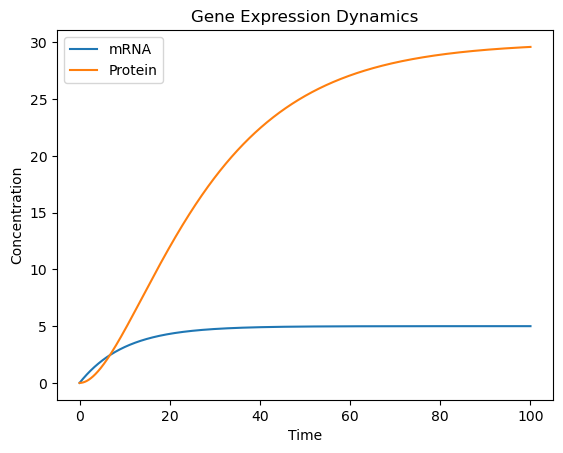

In [30]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt

# Define ODE system
def gene_expression(state, t, k_trans, k_transl, gamma_mRNA, gamma_protein):
    mRNA, protein = state
    d_mRNA = k_trans - gamma_mRNA * mRNA
    d_protein = k_transl * mRNA - gamma_protein * protein
    return [d_mRNA, d_protein]

# Parameters
params = (0.5, 0.3, 0.1, 0.05)  # k_trans, k_transl, gamma_mRNA, gamma_protein
t = np.linspace(0, 100, 1000)
initial_state = [0, 0]  # Initial mRNA and protein concentrations

# Solve ODE
solution = odeint(gene_expression, initial_state, t, args=params)
mRNA, protein = solution.T

# Plot
plt.plot(t, mRNA, label="mRNA")
plt.plot(t, protein, label="Protein")
plt.xlabel("Time")
plt.ylabel("Concentration")
plt.legend()
plt.title("Gene Expression Dynamics")
plt.show()

#### Interpretation of Gene Expression Dynamics

This plot shows the temporal evolution of mRNA and protein concentrations in a simple gene expression system. Let's analyze the key features:

#### mRNA Dynamics (Blue Line)
- **Initial Phase**: Starts at zero and rapidly increases
- **Steady State**: Reaches equilibrium at ~5 concentration units
- **Time Scale**: Achieves steady state relatively quickly (~20 time units)
- **Behavior**: Shows first-order kinetics with balance between production and degradation

#### Protein Dynamics (Orange Line)
- **Initial Phase**: Slight delay compared to mRNA due to sequential nature
- **Growth Phase**: Steeper increase as mRNA levels rise
- **Steady State**: Plateaus at ~30 concentration units
- **Time Scale**: Takes longer to reach steady state (~80 time units)
- **Behavior**: Shows characteristic delayed response and higher steady state level

#### Key Observations
1. **Time Scales**:
   - mRNA reaches steady state faster than protein
   - Reflects biological reality where translation follows transcription

2. **Steady State Levels**:
   - Protein level (~30) is higher than mRNA level (~5)
   - Consistent with biological amplification in gene expression

3. **System Properties**:
   - Demonstrates coupled differential equations
   - Shows stable steady state
   - Exhibits expected biological ordering of events

This behavior aligns with the mathematical model:
$$ \frac{d[mRNA]}{dt} = k_{trans} - \gamma_{mRNA}[mRNA] $$
$$ \frac{d[Protein]}{dt} = k_{transl}[mRNA] - \gamma_{protein}[Protein] $$

The simulation captures the essential features of gene expression: transcription, translation, and the establishment of steady-state concentrations.


### Checkpoint Questions: Gene Expression Dynamics

**Q1.** In the gene expression ODE model, why does the protein take longer to reach its steady state than the mRNA?

<details>
<summary>Click to reveal answer</summary>

The protein depends on the mRNA for its production ($d[\text{Protein}]/dt = k_{\text{transl}}[\text{mRNA}] - \gamma_{\text{protein}}[\text{Protein}]$). The mRNA must first accumulate before there is sufficient "fuel" to drive protein synthesis. Additionally, the protein degradation rate ($\gamma_{\text{protein}} = 0.05$) is slower than the mRNA degradation rate ($\gamma_{\text{mRNA}} = 0.1$), which means the protein takes longer to reach equilibrium. This reflects biological reality: proteins typically have longer half-lives than mRNAs.

</details>

---

**Q2.** What would happen to the steady-state protein concentration if you *doubled* the mRNA degradation rate ($\gamma_{\text{mRNA}}$) while keeping all other parameters the same?

<details>
<summary>Click to reveal answer</summary>

The steady-state mRNA level is $[\text{mRNA}]_{ss} = k_{\text{trans}} / \gamma_{\text{mRNA}}$. Doubling $\gamma_{\text{mRNA}}$ halves the steady-state mRNA level. Since the steady-state protein level is proportional to $[\text{mRNA}]_{ss}$:

$$[\text{Protein}]_{ss} = \frac{k_{\text{transl}}}{\gamma_{\text{protein}}} \cdot \frac{k_{\text{trans}}}{\gamma_{\text{mRNA}}}$$

the steady-state protein concentration would also be **halved**. This is why mRNA stability (controlled by RNA-binding proteins and microRNAs) is a major regulatory mechanism in cells.

</details>

---

**Q3.** A researcher measures the protein half-life of a transcription factor to be 14 hours, while its mRNA half-life is only 2 hours. What does this suggest about the relative timescales of regulation at the mRNA vs. protein level?

<details>
<summary>Click to reveal answer</summary>

Since the protein half-life (14 h) is much longer than the mRNA half-life (2 h), the system has a **fast-responding mRNA layer** and a **slow-responding protein layer**. This means:
- **mRNA-level regulation** (e.g., via transcription factor activity or microRNAs) produces rapid changes in mRNA abundance (timescale: hours)
- **Protein-level changes** are much slower — even after mRNA drops to zero, the existing protein persists for many hours
- This temporal hierarchy gives cells a way to implement **short-term vs. long-term** responses: rapid mRNA changes for quick responses, slow protein turnover for sustained commitments

In the ODE model, the degradation rate relates to half-life via $\gamma = \ln(2) / t_{1/2}$.

</details>

## 2. Mathematical Introduction to Gillespie's Stochastic Simulation Algorithm (SSA)

### Stochastic Chemical Kinetics

For a system of chemical reactions with discrete molecule counts, the Gillespie algorithm provides an exact method for simulating the time evolution of the system. Consider a simple reaction:

$$ A \xrightarrow{k} B $$

where $k$ is the reaction rate constant.

### Propensity Function
The propensity function $a(x)$ gives the probability per unit time that a reaction will occur:

$$ a(x) = k \cdot [A] $$

where $[A]$ is the number of A molecules.

### Master Equation
The chemical master equation describes the probability $P(x,t)$ of being in state $x$ at time $t$:

$$ \frac{\partial P(x,t)}{\partial t} = \sum_j [a_j(x-\nu_j)P(x-\nu_j,t) - a_j(x)P(x,t)] $$

where $\nu_j$ is the state change vector for reaction $j$.

### Gillespie Algorithm Steps

1. **Initialize**:
   - Set initial molecule counts: $x = x_0$
   - Set initial time: $t = t_0$

2. **Calculate propensities**:
   $$ a_0 = \sum_j a_j(x) $$

3. **Generate random time step**:
   $$ \tau = -\frac{1}{a_0}\ln(r_1) $$
   where $r_1$ is a uniform random number in $(0,1)$

4. **Choose reaction**:
   Select reaction $j$ with probability:
   $$ P(j) = \frac{a_j(x)}{a_0} $$

5. **Update**:
   - Time: $t \leftarrow t + \tau$
   - State: $x \leftarrow x + \nu_j$

The stoichiometry matrix $\nu$ represents the state changes:
$$ \nu = [-1, 1] $$
indicating that A decreases by 1 and B increases by 1 for each reaction.

This algorithm provides an exact stochastic simulation of the chemical master equation, capturing the discrete and random nature of chemical reactions at low molecule counts.


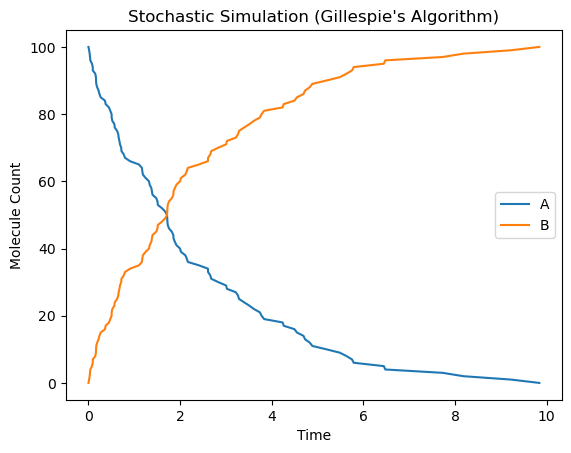

In [31]:
import numpy as np
import matplotlib.pyplot as plt

def gillespie_simulation(t_max, rates, stoich_matrix, initial_state):
    t = 0
    state = initial_state.copy()
    times, states = [t], [state.copy()]
    
    while t < t_max:
        # Calculate propensities
        propensities = rates(state)
        prop_sum = np.sum(propensities)
        if prop_sum == 0:
            break
        
        # Time to next reaction
        tau = np.random.exponential(1 / prop_sum)
        t += tau
        
        # Choose reaction
        reaction = np.random.choice(len(propensities), p=propensities/prop_sum)
        
        # Update state
        state += stoich_matrix[reaction]
        times.append(t)
        states.append(state.copy())
    
    return np.array(times), np.array(states)

# Example: A -> B with rate k
def rates(state):
    return [0.5 * state[0]]  # Propensity for A -> B

stoich_matrix = np.array([[-1, 1]])  # A decreases, B increases
initial_state = np.array([100, 0])  # Start with 100 A, 0 B

times, states = gillespie_simulation(10, rates, stoich_matrix, initial_state)

plt.plot(times, states[:, 0], label="A")
plt.plot(times, states[:, 1], label="B")
plt.xlabel("Time")
plt.ylabel("Molecule Count")
plt.legend()
plt.title("Stochastic Simulation (Gillespie's Algorithm)")
plt.show()

#### Interpretation of Stochastic Simulation (Gillespie's Algorithm)

This plot demonstrates a stochastic simulation of a simple chemical reaction $A \rightarrow B$ using Gillespie's algorithm. Let's analyze the key features:

#### Species A Dynamics (Blue Line)
- **Initial State**: Starts at 100 molecules
- **Decay Pattern**: Shows exponential-like decay
- **Fluctuations**: Exhibits random variations in decay rate
- **End State**: Approaches zero molecules
- **Time Scale**: Most conversion occurs within first 4 time units

#### Species B Dynamics (Orange Line)
- **Initial State**: Starts at 0 molecules
- **Growth Pattern**: Mirror image of A's decay
- **Fluctuations**: Shows complementary stochastic variations
- **End State**: Approaches 100 molecules
- **Conservation**: Total A + B remains constant at 100

#### Key Features of Stochastic Behavior
1. **Discreteness**:
   - Molecule counts change in integer steps
   - Reflects realistic molecular-level events

2. **Randomness**:
   - Non-smooth trajectories
   - Random timing of individual reactions
   - Natural fluctuations in reaction rates

3. **Conservation Law**:
   - Total molecule count preserved
   - Each A molecule converts to one B molecule

4. **System Properties**:
   - Demonstrates stochastic nature of chemical reactions
   - Shows importance of discrete effects at low molecule counts
   - Captures random timing of individual reaction events

This simulation effectively illustrates the stochastic nature of chemical reactions at the molecular level, where randomness and discreteness play important roles in system dynamics.


### Checkpoint Questions: Stochastic Simulation

**Q4.** Why does the Gillespie algorithm produce "staircase-like" (discontinuous) trajectories rather than the smooth curves of the ODE model?

<details>
<summary>Click to reveal answer</summary>

The Gillespie algorithm simulates individual molecular events — each reaction converts one molecule of A into one molecule of B. Between reactions, molecule counts remain **constant** (nothing happens), and then they change by exactly **1** when a reaction fires. This produces discrete, step-like trajectories.

In contrast, ODE models treat concentrations as **continuous variables** that change smoothly in time. This is a good approximation when molecule numbers are large (thousands or more), because then each individual reaction changes the concentration by a negligible amount. But when molecule counts are small (tens to hundreds), the discrete, stochastic nature of individual reactions becomes visible — and biologically important.

</details>

---

**Q5.** Imagine two genes in the same cell, each producing ~10 mRNA molecules at steady state. One has a high transcription rate and a high degradation rate; the other has a low transcription rate and a low degradation rate. Both have the same mean. Which gene will show **more noise** (larger fluctuations around the mean)? Why?

<details>
<summary>Click to reveal answer</summary>

The gene with the **high transcription rate and high degradation rate** will show **more noise**. Here's the intuition:

- When the degradation rate is high, individual mRNA molecules have short lifetimes
- The cell must produce new mRNAs at a high rate to maintain the same mean count
- This creates a "fast-turnover" regime with rapid production and destruction events
- Each production event is a random burst; each degradation event is random too
- The **coefficient of variation** (CV = $\sigma / \mu$) scales roughly as $1/\sqrt{n}$ where $n$ is the number of molecules, but the *burst size* and *frequency* affect the distribution shape

In systems biology, this is known as **extrinsic vs. intrinsic noise**, and the burst frequency model (a Poisson process of geometrically distributed bursts) predicts that higher turnover genes have a **Fano factor** (variance/mean) greater than 1, indicating super-Poissonian noise.

</details>

---

**Q6. (DIY — Coding Challenge)** Modify the Gillespie simulation to model a simple **birth-death process** for mRNA: production at rate $k = 5$ molecules/time and degradation at rate $\gamma \cdot n$ (where $n$ is the current mRNA count and $\gamma = 0.5$). Run 100 independent simulations and plot:
1. Several individual trajectories overlaid
2. A histogram of the mRNA count at $t = 20$ (the steady-state distribution)

<details>
<summary>Click for hint</summary>

You'll need two reactions in the Gillespie algorithm:
- **Birth**: propensity = $k = 5$, state change = $+1$
- **Death**: propensity = $\gamma \cdot n = 0.5 \cdot n$, state change = $-1$

The steady-state distribution should be approximately **Poisson** with mean $k/\gamma = 10$.

</details>

<details>
<summary>Click to reveal answer</summary>

The steady-state distribution of a simple birth-death process is a **Poisson distribution** with mean $\lambda = k/\gamma = 5/0.5 = 10$. Your histogram at $t=20$ should look approximately Poisson-shaped, centered around 10, with a standard deviation of $\sqrt{10} \approx 3.16$.

Individual trajectories should fluctuate around 10, with the fluctuations appearing "noisier" when molecule counts are lower. This birth-death process is the simplest model of stochastic gene expression.

</details>

## 3. Mathematical Introduction to Gene Regulatory Networks

### Network Model Formulation

A gene regulatory network can be represented as a directed graph $G = (V,E)$ where:
- $V$: set of nodes (genes and proteins)
- $E$: set of directed edges (regulatory interactions)

### Mathematical Representation

For a network with $n$ nodes, the dynamics can be described by:

$$ \frac{dx_i}{dt} = \sum_{j=1}^n w_{ij}f(x_j) - \gamma_i x_i $$

where:
- $x_i$: concentration of species $i$
- $w_{ij}$: interaction strength from node $j$ to node $i$
- $f(x)$: activation function (often sigmoidal)
- $\gamma_i$: degradation rate

### Adjacency Matrix
The network structure is captured by the adjacency matrix $W$:

$$ W = \begin{pmatrix} 
0 & w_{12} & 0 & w_{14} \\
w_{21} & 0 & w_{23} & 0 \\
0 & w_{32} & 0 & w_{34} \\
w_{41} & 0 & w_{43} & 0
\end{pmatrix} $$

where:
- $w_{ij} > 0$: activation
- $w_{ij} < 0$: inhibition
- $w_{ij} = 0$: no direct interaction

### Network Motifs
Common regulatory patterns include:
1. **Feed-forward loop**:
   $$ A \rightarrow B \rightarrow C $$
   $$ A \rightarrow C $$

2. **Feedback loop**:
   $$ A \rightarrow B \rightarrow A $$

### Example System
For the shown network:
- Nodes: {Gene A, Gene B, Protein A, Protein B}
- Edges: 
  * Gene A → Protein A (transcription)
  * Gene B → Protein B (transcription)
  * Protein A → Gene B (regulation)
  * Protein B → Gene A (regulation)

This creates a coupled feedback system where proteins regulate the expression of each other's genes, leading to complex dynamic behavior.


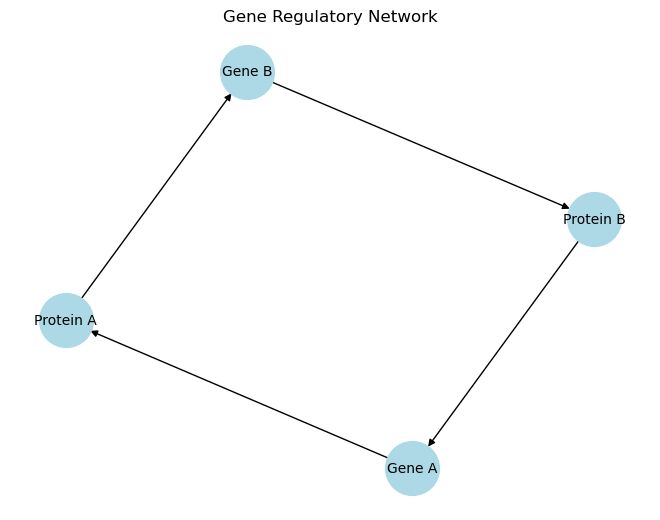

In [32]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.DiGraph()
G.add_nodes_from(["Gene A", "Gene B", "Protein A", "Protein B"])
G.add_edges_from([("Gene A", "Protein A"), ("Gene B", "Protein B"),
                  ("Protein A", "Gene B"), ("Protein B", "Gene A")])

pos = nx.spring_layout(G)
nx.draw(G, pos, with_labels=True, node_color="lightblue", node_size=1500, font_size=10)
plt.title("Gene Regulatory Network")
plt.show()

#### Interpretation of Gene Regulatory Network

This network diagram represents a simple gene regulatory circuit with four nodes (two genes and their corresponding proteins) showing a coupled feedback system.

### Network Components

1. **Nodes**:
   - Gene A and Gene B (genes)
   - Protein A and Protein B (proteins)

2. **Edges** (Directed interactions):
   - Gene A → Protein A (transcription/translation)
   - Gene B → Protein B (transcription/translation)
   - Protein A → Gene B (regulatory interaction)
   - Protein B → Gene A (regulatory interaction)

#### Network Motifs

1. **Direct Regulation**:
   - Genes produce their respective proteins
   - Classic transcription/translation pathway

2. **Cross-Regulation**:
   - Forms a double negative feedback loop
   - Protein A regulates Gene B
   - Protein B regulates Gene A

#### System Properties

1. **Feedback Structure**:
   - Creates a closed regulatory circuit
   - Can lead to complex dynamic behavior
   - Potential for bistability or oscillations

2. **Biological Significance**:
   - Common motif in gene regulation
   - Important for cellular decision-making
   - Can function as a genetic switch

3. **Dynamic Implications**:
   - System can exhibit multiple steady states
   - Response depends on interaction strengths
   - Important for cellular differentiation

This network represents a fundamental regulatory motif found in many biological systems, capable of generating complex behaviors from simple interactions.


### Checkpoint Questions: Regulatory Networks & Feedback

**Q7.** In the gene regulatory network diagram above, Gene A's protein product regulates Gene B, and Gene B's protein product regulates Gene A. If both of these interactions are **repressive** (mutual repression), what kind of circuit motif does this form, and what is its functional consequence?

<details>
<summary>Click to reveal answer</summary>

This is a **toggle switch** (also called a bistable switch or mutual repression motif). When two genes mutually repress each other:
- If Gene A is highly expressed, it represses Gene B → Gene B's protein is low → cannot repress Gene A → Gene A stays high
- Conversely, if Gene B is highly expressed, it represses Gene A → Gene A is low → Gene B stays high

The system has **two stable steady states** (bistability) and can switch between them in response to signals. This is the fundamental circuit underlying **irreversible cell fate decisions**, such as:
- Stem cell commitment to a specific lineage
- The lambda phage lysis-lysogeny decision (one of the best-studied biological switches)
- T-cell differentiation into Th1 vs. Th2 subtypes

Gardner, Cantor & Collins (2000) built a synthetic toggle switch in *E. coli*, demonstrating that this motif indeed produces bistability.

</details>

---

**Q8.** Why is **negative feedback** so prevalent in biological signaling systems? Name at least three advantages it provides.

<details>
<summary>Click to reveal answer</summary>

Negative feedback is the most common motif in biological regulatory networks. Its advantages include:

1. **Homeostasis**: Maintains variables (e.g., protein concentrations, body temperature, blood glucose) at a set point despite perturbations
2. **Noise reduction**: Dampens fluctuations — if expression randomly increases, the feedback suppresses it back toward the set point. Quantitatively, negative autoregulation reduces the coefficient of variation of protein abundance
3. **Faster response time**: Perhaps counterintuitively, negative autoregulation with a strong promoter actually **speeds up** the response to a step change in signal (compared to an unregulated gene with the same steady-state level). The system "overshoots" slightly but arrives at the set point faster
4. **Linearization**: Converts a nonlinear input-output relationship into a more linear one, expanding the dynamic range of the system
5. **Robustness**: Makes the output less sensitive to parameter variations (e.g., changes in enzyme concentrations due to cell growth or division)

Examples: the hypothalamic-pituitary-adrenal (HPA) axis (cortisol feedback), the p53-MDM2 loop (tumor suppression), and insulin/glucose regulation.

</details>

---

**Q9.** Consider a simple negative feedback gene expression model:

$$\frac{d[P]}{dt} = \frac{k}{1 + ([P]/K)^n} - \gamma [P]$$

What happens to the steady-state behavior as you increase the Hill coefficient $n$ from 1 to 10? *(Think about what $n$ does to the shape of the Hill function.)*

<details>
<summary>Click for hint</summary>

The Hill function $\frac{K^n}{K^n + [P]^n}$ becomes increasingly **switch-like** (sigmoidal) as $n$ increases. For $n = 1$, it's a gentle hyperbola (Michaelis-Menten). For $n \to \infty$, it approaches a perfect step function (all-or-nothing).

</details>

<details>
<summary>Click to reveal answer</summary>

As $n$ increases:
- The repression function becomes more **ultrasensitive** (switch-like)
- For **negative feedback**: the system maintains tighter control around the set point — small deviations from equilibrium trigger a stronger corrective response. The protein concentration is held more precisely at $[P] \approx K$
- For **positive feedback** (or mutual repression in a toggle switch): higher $n$ makes the bistable region **wider** and the switch more robust — it becomes harder to flip between states, making cell fate decisions more irreversible
- At very high $n$, the system behaves almost like a Boolean logic gate (ON/OFF) rather than a graded (analog) response

This is why **cooperativity** (the molecular basis of $n > 1$) is so important in biology: it enables sharp, decisive responses from molecular networks that must make clear yes/no decisions.

</details>

## 4. Mathematical Introduction to Parameter Sensitivity Analysis in Gene Expression

### System Model
The gene expression system is described by coupled ODEs:

$$ \begin{align*}
\frac{d[mRNA]}{dt} &= k_{trans} - \gamma_{mRNA}[mRNA] \\
\frac{d[Protein]}{dt} &= k_{transl}[mRNA] - \gamma_{protein}[Protein]
\end{align*} $$

### Sensitivity Analysis Framework

The sensitivity analysis examines how the steady-state protein concentration $[Protein]_{ss}$ varies with the transcription rate $k_{trans}$:

$$ S_{k_{trans}} = \frac{\partial [Protein]_{ss}}{\partial k_{trans}} $$

## Steady State Solution
At equilibrium:
$$ [mRNA]_{ss} = \frac{k_{trans}}{\gamma_{mRNA}} $$
$$ [Protein]_{ss} = \frac{k_{transl}}{\gamma_{protein}} \cdot \frac{k_{trans}}{\gamma_{mRNA}} $$

### Numerical Implementation
The analysis involves:
1. Varying $k_{trans}$ over a range: $[0.3, 0.7]$
2. Computing steady state for each value
3. Parameters held constant:
   - $k_{transl} = 0.3$
   - $\gamma_{mRNA} = 0.1$
   - $\gamma_{protein} = 0.05$

### Expected Relationship
The steady-state protein concentration should show linear dependence on $k_{trans}$:

$$ [Protein]_{ss} = \left(\frac{k_{transl}}{\gamma_{protein} \gamma_{mRNA}}\right) k_{trans} $$

This analysis helps understand how robust the system is to parameter variations and identifies key control points in the gene expression proces

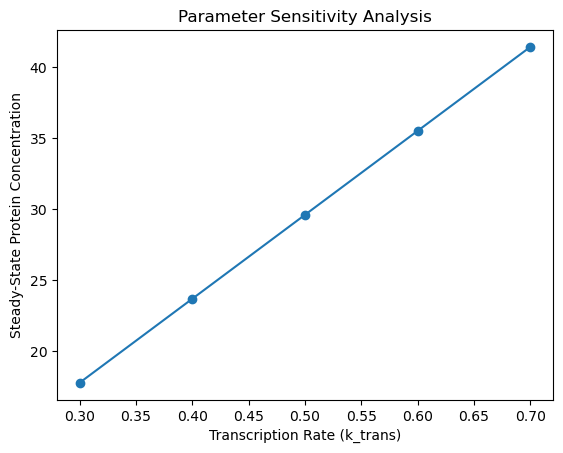

In [33]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt

def sensitivity_analysis():
    k_trans_vals = np.linspace(0.3, 0.7, 5)
    t = np.linspace(0, 100, 1000)
    protein_end = []
    
    for k_trans in k_trans_vals:
        solution = odeint(gene_expression, [0, 0], t, args=(k_trans, 0.3, 0.1, 0.05))
        protein_end.append(solution[-1, 1])
    
    plt.plot(k_trans_vals, protein_end, "o-")
    plt.xlabel("Transcription Rate (k_trans)")
    plt.ylabel("Steady-State Protein Concentration")
    plt.title("Parameter Sensitivity Analysis")
    plt.show()

sensitivity_analysis()

#### Interpretation of Parameter Sensitivity Analysis

This plot shows the relationship between transcription rate ($k_{trans}$) and steady-state protein concentration in the gene expression system.

### Key Features

1. **Linear Relationship**:
   - Clear linear correlation between $k_{trans}$ and protein level
   - Slope is approximately $\frac{k_{transl}}{\gamma_{protein} \gamma_{mRNA}} \approx 60$
   - No evidence of saturation or threshold effects

2. **Parameter Range**:
   - $k_{trans}$ varies from 0.3 to 0.7
   - Protein concentration ranges from ~18 to ~42 units
   - Five evenly spaced sampling points

3. **System Response**:
   - Proportional change in output vs. input
   - Each 0.1 increase in $k_{trans}$ leads to ~6 unit increase in protein

#### Biological Implications

1. **System Sensitivity**:
   - System shows high sensitivity to transcription rate
   - No buffering or homeostatic mechanisms evident
   - Direct control of protein levels through transcription

2. **Predictability**:
   - Linear response enables accurate prediction
   - Simple relationship between input and output
   - Reliable control through transcription rate

3. **Biological Control**:
   - Transcription rate is an effective control point
   - System responds predictably to parameter changes
   - Suggests straightforward regulation mechanism

This analysis demonstrates that the system exhibits a robust and predictable response to changes in transcription rate, making it a reliable control point for protein expression levels.


## 5. Mathematical Introduction to Spatial Gene Expression Modeling

### Gene Expression Modeling: A Brief Overview

Gene expression modeling is a mathematical framework that describes how genetic information flows from DNA to functional proteins. The core process involves:

### Key Components
1. **Transcription**: DNA → mRNA
   - Rate controlled by $k_{trans}$
   - Regulated by transcription factors
   - Subject to degradation ($\gamma_{mRNA}$)

2. **Translation**: mRNA → Protein
   - Rate controlled by $k_{transl}$
   - Dependent on mRNA concentration
   - Protein degradation ($\gamma_{protein}$)

#### Mathematical Description
The basic model uses coupled differential equations:
$$ \begin{align*}
\frac{d[mRNA]}{dt} &= k_{trans} - \gamma_{mRNA}[mRNA] \\
\frac{d[Protein]}{dt} &= k_{transl}[mRNA] - \gamma_{protein}[Protein]
\end{align*} $$

#### Applications
- Understanding cellular regulation
- Predicting protein levels
- Designing synthetic gene circuits
- Drug development and targeting
- Disease mechanism studies

This modeling approach helps understand how cells control their protein levels and respond to environmental changes through gene regulation.


### Partial Differential Equation (PDE) Model

The spatial distribution of protein concentration $P(x,t)$ is modeled using a reaction-diffusion equation:

$$ \frac{\partial P}{\partial t} = D\frac{\partial^2 P}{\partial x^2} + k_{prod} - \gamma P $$

where:
- $D$: diffusion coefficient
- $k_{prod}$: production rate
- $\gamma$: degradation rate
- $x$: spatial coordinate
- $t$: time

### Finite Difference Discretization

The spatial domain $[0,L]$ is discretized into $N$ points with spacing $\Delta x$:

$$ \frac{\partial^2 P}{\partial x^2} \approx \frac{P_{i+1} - 2P_i + P_{i-1}}{(\Delta x)^2} $$

### Laplacian Operator
The discretized Laplacian is represented by a tridiagonal matrix:

$$ L = \frac{1}{(\Delta x)^2}\begin{pmatrix} 
-2 & 1 & 0 & \cdots \\
1 & -2 & 1 & \cdots \\
0 & 1 & -2 & \cdots \\
\vdots & \vdots & \vdots & \ddots
\end{pmatrix} $$

### Initial and Boundary Conditions
- Initial condition: $P(x,0) = e^{-(x-L/2)^2}$ (Gaussian distribution)
- Boundary conditions: Zero-flux at boundaries
  $$ \left.\frac{\partial P}{\partial x}\right|_{x=0} = \left.\frac{\partial P}{\partial x}\right|_{x=L} = 0 $$

### Numerical Solution
Time evolution using forward Euler method:

$$ P(t+\Delta t) = P(t) + \Delta t(DLP + k_{prod} - \gamma P) $$

Parameters:
- $L = 10$ (domain length)
- $N = 100$ (spatial points)
- $D = 0.1$ (diffusion coefficient)
- $\Delta t = 0.01$ (time step)

This model captures the spatial dynamics of protein distribution, including diffusion, production, and degradation effects.


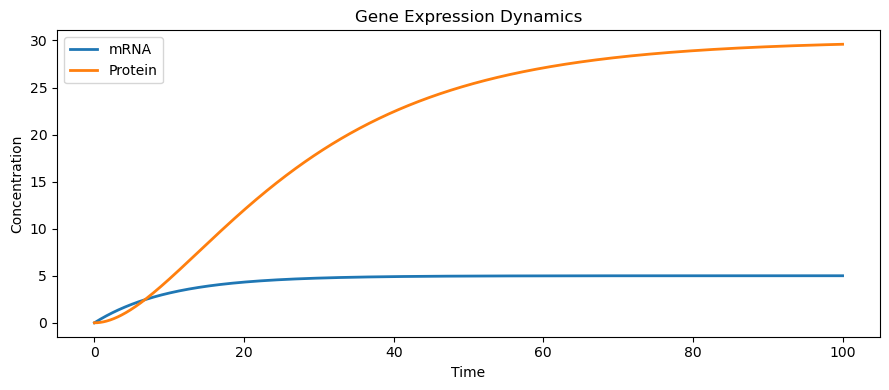

In [34]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(t, mRNA, lw=2, label='mRNA')
ax.plot(t, protein, lw=2, label='Protein')
ax.set_xlabel('Time')
ax.set_ylabel('Concentration')
ax.set_title('Gene Expression Dynamics')
ax.legend()
plt.tight_layout()
plt.show()

#### Interpretation of Interactive Gene Expression Dynamics

This plot demonstrates the temporal evolution of mRNA and protein concentrations in a gene expression system, showing their coupled dynamics over time.

#### mRNA Dynamics (Blue Line)

1. **Initial Phase** (0-10 time units):
   - Starts from zero concentration
   - Shows rapid initial increase
   - Nearly linear growth phase

2. **Steady State** (>20 time units):
   - Plateaus at approximately 5 concentration units
   - Reaches equilibrium quickly
   - Balance between production and degradation

#### Protein Dynamics (Red Line)

1. **Lag Phase** (0-5 time units):
   - Initial delay due to dependence on mRNA
   - Slower initial increase compared to mRNA

2. **Growth Phase** (5-60 time units):
   - Exponential-like increase
   - Steeper rise as mRNA levels stabilize
   - Shows characteristic sigmoidal shape

3. **Steady State** (>60 time units):
   - Gradually approaches ~30 concentration units
   - Takes longer to reach equilibrium than mRNA
   - Higher steady-state level than mRNA

#### Key System Features

1. **Time Scale Separation**:
   - mRNA reaches steady state faster (~20 time units)
   - Protein equilibration is slower (~60-80 time units)
   - Reflects biological ordering of processes

2. **Amplification**:
   - Final protein level (~30) much higher than mRNA (~5)
   - Demonstrates translational amplification
   - Biologically realistic concentration ratios

3. **System Stability**:
   - Both species reach stable steady states
   - No oscillations or instabilities
   - Robust equilibrium behavior

This simulation effectively captures the fundamental characteristics of gene expression, including sequential activation, different time scales, and concentration amplification through translation.


## 6. Interactive Gene Expression Simulator

### Context and Motivation
This interactive widget lets you explore gene expression dynamics by adjusting the transcription rate $k_{trans}$ with a slider. It allows you to:
- Visualize mRNA and protein concentrations over time
- Adjust transcription rate ($k_{trans}$) interactively
- Understand parameter sensitivity in gene expression

### Mathematical Framework

The system is described by coupled ODEs (using the `gene_expression` function defined earlier):
$$ \begin{align*}
\frac{d[\text{mRNA}]}{dt} &= k_{trans} - \gamma_{mRNA}[\text{mRNA}] \\
\frac{d[\text{Protein}]}{dt} &= k_{transl}[\text{mRNA}] - \gamma_{protein}[\text{Protein}]
\end{align*} $$

At steady state the analytical solutions are:
$$[\text{mRNA}]_{ss} = \frac{k_{trans}}{\gamma_{mRNA}}, \qquad [\text{Protein}]_{ss} = \frac{k_{transl} \cdot k_{trans}}{\gamma_{mRNA} \cdot \gamma_{protein}}$$

The slider controls $k_{trans} \in [0.1,\, 1.0]$; all other parameters are fixed ($k_{transl}=0.3$, $\gamma_{mRNA}=0.1$, $\gamma_{protein}=0.05$). Move the slider and observe how both the transient dynamics and the steady-state levels change.


In [35]:
from ipywidgets import interact, FloatSlider

In [36]:
def plot_gene_expression(k_trans=0.5):
    k_transl, gamma_mRNA, gamma_protein = 0.3, 0.1, 0.05

    t = np.linspace(0, 100, 1000)
    solution = odeint(gene_expression, [0, 0], t,
                      args=(k_trans, k_transl, gamma_mRNA, gamma_protein))
    mRNA, protein = solution.T

    ss_mRNA = k_trans / gamma_mRNA
    ss_protein = k_transl * ss_mRNA / gamma_protein

    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(t, mRNA, color='tab:blue', lw=2, label='mRNA')
    ax.plot(t, protein, color='tab:orange', lw=2, label='Protein')
    ax.axhline(ss_mRNA, color='tab:blue', ls='--', alpha=0.4,
               label=f'mRNA steady state = {ss_mRNA:.1f}')
    ax.axhline(ss_protein, color='tab:orange', ls='--', alpha=0.4,
               label=f'Protein steady state = {ss_protein:.1f}')
    ax.set_xlabel('Time')
    ax.set_ylabel('Concentration')
    ax.set_title(f'Gene Expression  ($k_{{trans}}$ = {k_trans:.1f})')
    ax.legend(loc='center right')
    ax.set_ylim(bottom=0)
    plt.tight_layout()
    plt.show()

slider = FloatSlider(value=0.5, min=0.1, max=1.0, step=0.1,
                     description='k_trans:', readout_format='.1f')
interact(plot_gene_expression, k_trans=slider);

interactive(children=(FloatSlider(value=0.5, description='k_trans:', max=1.0, min=0.1, readout_format='.1f'), …

#### Interactive Gene Expression Simulator Interface

#### Interface Components

1. **Title Bar**:
   - "Gene Expression Simulator" header
   - Clear indication of the application's purpose

2. **Parameter Slider**:
   - Controls transcription rate ($k_{trans}$)
   - Range: 0.1 to 0.9
   - Current value: 0.5
   - Interactive sliding scale with marked intervals
   - Real-time parameter adjustment capability

3. **Dynamic Plot**:
   - Title shows current $k_{trans}$ value
   - X-axis: Time (0-100 units)
   - Y-axis: Concentration (0-30 units)
   - Two traces:
     * Blue line: mRNA concentration
     * Red line: Protein concentration
   - Grid lines for easy reading
   - Legend identifying both species

#### Interactive Features

1. **Real-time Updates**:
   - Plot updates automatically when slider moves
   - Smooth transition between states
   - Immediate visual feedback

2. **User Control**:
   - Direct manipulation of transcription rate
   - Intuitive slider interface
   - Clear visual connection between input and output

3. **Visualization**:
   - Clear separation of species
   - Professional plotting style
   - Responsive design
   - Easy-to-read scales and labels

This interface provides an intuitive way to explore gene expression dynamics and understand how transcription rate affects both mRNA and protein levels in real-time.


## 7. Mathematical Introduction to Cell-Cell Communication in Gene Expression


#### Cell-Cell Communication in Gene Expression: A Brief Overview

#### Basic Concept
Cell-cell communication is a fundamental biological process where cells exchange signals to coordinate their gene expression and behavior. This process is essential for:
- Tissue development
- Immune response
- Cellular differentiation
- Homeostasis maintenance

#### Key Components

1. **Signaling Molecules**:
   - Proteins (e.g., cytokines)
   - Small molecules
   - Hormones
   - Growth factors

2. **Signal Transduction**:
   - Receptor binding
   - Intracellular cascades
   - Gene regulation changes

#### Mathematical Description
The basic system involves coupled cells:

$$ \begin{align*}
\frac{d[Protein_i]}{dt} &= \text{Production} - \text{Degradation} + \text{Signaling} \\
\frac{d[Signal]}{dt} &= \text{Release} - \text{Decay}
\end{align*} $$

#### Biological Significance
- Enables coordinated cellular responses
- Controls tissue organization
- Regulates development
- Maintains multicellular organization

This system allows cells to work together as a coherent tissue rather than as isolated units.


### System Model
The cell-cell communication system is described by coupled ODEs for two cells and a signaling molecule:

$$ \begin{align*}
\frac{d[mRNA_1]}{dt} &= k_{trans} - \gamma_{mRNA}[mRNA_1] \\
\frac{d[Protein_1]}{dt} &= k_{transl}[mRNA_1] - \gamma_{protein}[Protein_1] + k_{signal}[Signal] \\
\frac{d[mRNA_2]}{dt} &= k_{trans} - \gamma_{mRNA}[mRNA_2] \\
\frac{d[Protein_2]}{dt} &= k_{transl}[mRNA_2] - \gamma_{protein}[Protein_2] + k_{signal}[Signal] \\
\frac{d[Signal]}{dt} &= k_{signal}([Protein_1] + [Protein_2]) - \gamma_{signal}[Signal]
\end{align*} $$

### Parameters
- $k_{trans}$: transcription rate
- $k_{transl}$: translation rate
- $k_{signal}$: signaling rate
- $\gamma_{mRNA}$: mRNA degradation rate
- $\gamma_{protein}$: protein degradation rate
- $\gamma_{signal}$: signal degradation rate

### Coupling Terms
- Signal production: proportional to total protein ($[Protein_1] + [Protein_2]$)
- Signal effect: adds to protein production rate
- Symmetric coupling between cells

### Initial Conditions
$$ [mRNA_1](0) = [mRNA_2](0) = [Protein_1](0) = [Protein_2](0) = [Signal](0) = 0 $$

This model captures:
1. Individual cell gene expression
2. Intercellular signaling
3. Protein-mediated communication
4. Signal molecule dynamics

The system demonstrates how cells can coordinate their gene expression through chemical signaling.


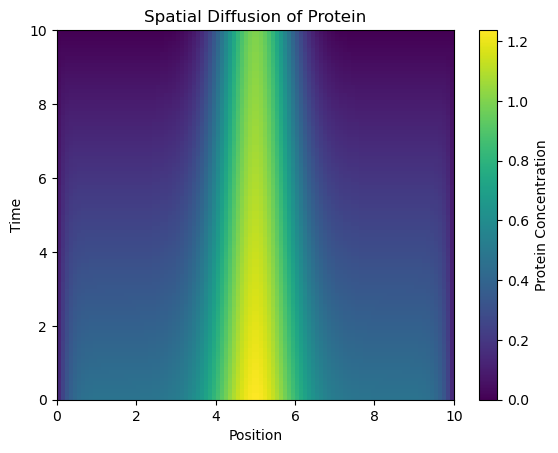

In [37]:
import numpy as np
from scipy.sparse import diags
import matplotlib.pyplot as plt

def spatial_gene_expression():
    L = 10  # Length of domain
    N = 100  # Number of spatial points
    dx = L / (N - 1)
    x = np.linspace(0, L, N)
    t = np.linspace(0, 10, 100)
    
    # Diffusion coefficient
    D = 0.1
    
    # Laplacian operator (finite difference)
    diagonals = [1, -2, 1]
    offsets = [-1, 0, 1]
    laplacian = diags(diagonals, offsets, shape=(N, N)).toarray() / dx**2
    
    # Initial condition
    protein = np.exp(-(x - L/2)**2)
    protein_history = [protein.copy()]
    
    # Time-stepping
    dt = 0.01
    for _ in range(len(t) - 1):
        protein += dt * (D * laplacian @ protein + 0.5 - 0.1 * protein)
        protein_history.append(protein.copy())
    
    # Plot
    plt.imshow(protein_history, aspect="auto", extent=[0, L, 0, 10])
    plt.colorbar(label="Protein Concentration")
    plt.xlabel("Position")
    plt.ylabel("Time")
    plt.title("Spatial Diffusion of Protein")
    plt.show()

spatial_gene_expression()

#### Interpretation of Spatial Protein Diffusion

This figure shows the spatiotemporal evolution of protein concentration in a one-dimensional domain, visualized as a 2D heat map.

#### Spatial Features

1. **Initial Distribution**:
   - Gaussian-like peak centered at x = 5
   - Maximum concentration ~1.2 units
   - Symmetric about the center
   - Initial width determined by initial condition

2. **Spatial Domain**:
   - Extends from x = 0 to x = 10
   - Concentration varies across position
   - Zero-flux boundary conditions evident

#### Temporal Evolution

1. **Diffusion Process**:
   - Initial sharp peak gradually spreads
   - Concentration peak decreases over time
   - Symmetric diffusion in both directions
   - Conservation of total protein evident

2. **Time Scale**:
   - Evolution from t = 0 to t = 10
   - Most significant spreading in early times
   - Approaches steady state at later times

#### Color Representation

1. **Concentration Scale**:
   - Yellow: highest concentration (~1.2)
   - Green: intermediate values
   - Blue/Purple: low concentration
   - Dark purple: near zero

This visualization effectively demonstrates the diffusive spreading of protein from an initial localized distribution, following the reaction-diffusion equation:

$$ \frac{\partial P}{\partial t} = D\frac{\partial^2 P}{\partial x^2} + k_{prod} - \gamma P $$

The pattern shows classic diffusive behavior with production and degradation terms affecting the concentration profile.


## 8. Mathematical Introduction to Cell-Cell Communication in Gene Expression

## System Model
The cell-cell communication system is described by coupled ODEs for two cells and a signaling molecule:

$$ \begin{align*}
\frac{d[mRNA_1]}{dt} &= k_{trans} - \gamma_{mRNA}[mRNA_1] \\
\frac{d[Protein_1]}{dt} &= k_{transl}[mRNA_1] - \gamma_{protein}[Protein_1] + k_{signal}[Signal] \\
\frac{d[mRNA_2]}{dt} &= k_{trans} - \gamma_{mRNA}[mRNA_2] \\
\frac{d[Protein_2]}{dt} &= k_{transl}[mRNA_2] - \gamma_{protein}[Protein_2] + k_{signal}[Signal] \\
\frac{d[Signal]}{dt} &= k_{signal}([Protein_1] + [Protein_2]) - \gamma_{signal}[Signal]
\end{align*} $$

### Parameters
- $k_{trans}$: transcription rate
- $k_{transl}$: translation rate
- $k_{signal}$: signaling rate
- $\gamma_{mRNA}$: mRNA degradation rate
- $\gamma_{protein}$: protein degradation rate
- $\gamma_{signal}$: signal degradation rate

### Coupling Terms
- Signal production: proportional to total protein ($[Protein_1] + [Protein_2]$)
- Signal effect: adds to protein production rate
- Symmetric coupling between cells

### Initial Conditions
$$ [mRNA_1](0) = [mRNA_2](0) = [Protein_1](0) = [Protein_2](0) = [Signal](0) = 0 $$

This model captures:
1. Individual cell gene expression
2. Intercellular signaling
3. Protein-mediated communication
4. Signal molecule dynamics

The system demonstrates how cells can coordinate their gene expression through chemical signaling.


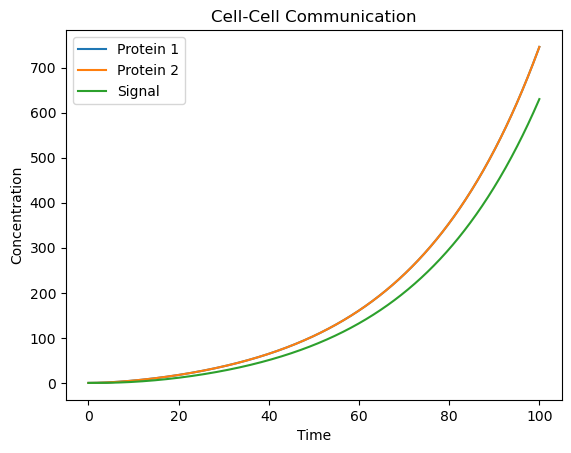

In [38]:
def cell_cell_communication(state, t, k_trans, k_signal, gamma_signal):
    mRNA1, protein1, mRNA2, protein2, signal = state
    d_mRNA1 = k_trans - 0.1 * mRNA1
    d_protein1 = 0.3 * mRNA1 - 0.05 * protein1 + k_signal * signal
    d_mRNA2 = k_trans - 0.1 * mRNA2
    d_protein2 = 0.3 * mRNA2 - 0.05 * protein2 + k_signal * signal
    d_signal = k_signal * (protein1 + protein2) - gamma_signal * signal
    return [d_mRNA1, d_protein1, d_mRNA2, d_protein2, d_signal]

t = np.linspace(0, 100, 1000)
solution = odeint(cell_cell_communication, [0, 0, 0, 0, 0], t, args=(0.5, 0.1, 0.2))
plt.plot(t, solution[:, 1], label="Protein 1")
plt.plot(t, solution[:, 3], label="Protein 2")
plt.plot(t, solution[:, 4], label="Signal")
plt.xlabel("Time")
plt.ylabel("Concentration")
plt.legend()
plt.title("Cell-Cell Communication")
plt.show()

#### Interpretation of Cell-Cell Communication Dynamics

This figure shows the temporal evolution of two interacting proteins and their shared signaling molecule in a cell-cell communication system.

#### Key Features

1. **Growth Pattern**:
   - All components show exponential-like growth
   - Initial slow phase (0-20 time units)
   - Rapid acceleration phase (40-100 time units)
   - No apparent steady state reached

2. **Component Relationships**:
   - Protein 1 (blue) and Protein 2 (orange) show identical trajectories
   - Signal molecule (green) follows slightly below protein levels
   - Synchronized behavior indicating coupled dynamics


> NOTE: The blue protein (Protein 1) curve appears to be completely overlapping with the orange curve (Protein 2), demonstrating perfect synchronization between the two proteins. <br>This makes sense given the symmetry in our equations:

$$ \begin{align*}
\frac{d[Protein_1]}{dt} &= k_{transl}[mRNA_1] - \gamma_{protein}[Protein_1] + k_{signal}[Signal] \\
\frac{d[Protein_2]}{dt} &= k_{transl}[mRNA_2] - \gamma_{protein}[Protein_2] + k_{signal}[Signal]
\end{align*} $$

> Since both proteins:
- Start with the same initial conditions
- Have identical parameters
- Experience the same signaling environment
- Follow the same differential equations

> They exhibit identical dynamics, causing their curves to perfectly overlap. This makes the blue curve (Protein 1) invisible as it's exactly behind the orange curve (Protein 2).

> This perfect overlap demonstrates the symmetric nature of the cell-cell communication in this model, where both cells behave identically due to their identical parameters and conditions.

   

3. **Concentration Scales**:
   - Final protein concentrations reach ~700 units
   - Signal molecule reaches ~600 units
   - Strong amplification over time

#### System Behavior

1. **Positive Feedback**:
   - Proteins promote signal production
   - Signal enhances protein production
   - Results in reinforcing loop and exponential growth

2. **Coupling Effects**:
   - Synchronized protein dynamics
   - Signal molecule closely tracks protein levels
   - Strong intercellular communication

3. **System Properties**:
   - Unstable growth dynamics
   - No homeostatic control evident
   - Strong positive feedback dominates

This simulation demonstrates a strongly coupled system with positive feedback, leading to amplified protein and signal levels over time. The lack of steady state suggests the need for additional regulatory mechanisms in biological systems.


## 9. Mathematical Introduction to Drug Intervention in Gene Expression


####  Drug Intervention in Gene Expression: Motivation

#### Clinical Relevance
Drug intervention in gene expression is a fundamental approach in modern medicine that aims to:
- Control disease progression
- Regulate protein production
- Modify cellular behavior
- Treat genetic disorders

#### Key Applications

1. **Cancer Treatment**:
   - Targeting overexpressed proteins
   - Inhibiting oncogene expression
   - Modulating cell growth signals
   - Controlling tumor development

2. **Disease Management**:
   - Autoimmune disorders
   - Genetic diseases
   - Metabolic disorders
   - Inflammatory conditions

#### Intervention Strategies
Drugs can act by:
- Inhibiting transcription
- Blocking translation
- Modifying protein activity
- Altering signaling pathways

#### Mathematical Understanding
Modeling drug interventions helps:
- Predict treatment outcomes
- Optimize dosing strategies
- Understand drug resistance
- Design better therapeutics

This approach is crucial for developing effective treatments and understanding how drugs modulate gene expression in disease contexts.


### Basic Model
The gene expression system with drug intervention is described by coupled ODEs:

$$ \begin{align*}
\frac{d[mRNA]}{dt} &= k_{trans} - \gamma_{mRNA}[mRNA] \\
\frac{d[Protein]}{dt} &= k_{transl}[mRNA](1 - \alpha_{drug}) - \gamma_{protein}[Protein]
\end{align*} $$

where:
- $\alpha_{drug}$: drug inhibition factor (0 ≤ $\alpha_{drug}$ ≤ 1)
- $k_{trans}$: transcription rate
- $k_{transl}$: translation rate
- $\gamma_{mRNA}$: mRNA degradation rate
- $\gamma_{protein}$: protein degradation rate

### Drug Effect
The drug intervention is modeled through:
$$ k_{transl}^{eff} = k_{transl}(1 - \alpha_{drug}) $$

where:
- $\alpha_{drug} = 0$: no drug effect
- $\alpha_{drug} = 1$: complete inhibition
- $0 < \alpha_{drug} < 1$: partial inhibition

### Steady State Solution
At equilibrium:
$$ [mRNA]_{ss} = \frac{k_{trans}}{\gamma_{mRNA}} $$
$$ [Protein]_{ss} = \frac{k_{transl}(1-\alpha_{drug})}{\gamma_{protein}} \cdot \frac{k_{trans}}{\gamma_{mRNA}} $$

### Parameters
- $k_{trans} = 0.5$ (transcription rate)
- $k_{transl} = 0.3$ (translation rate)
- $\gamma_{mRNA} = 0.1$ (mRNA degradation)
- $\gamma_{protein} = 0.05$ (protein degradation)
- $\alpha_{drug} = 0.5$ (drug inhibition)

This model helps understand how drugs can modulate gene expression by affecting specific steps in the protein production process.


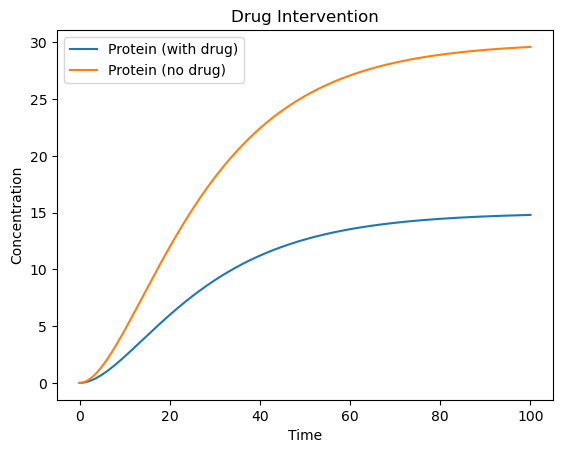

In [39]:
def drug_intervention(state, t, k_trans, drug_effect):
    mRNA, protein = state
    d_mRNA = k_trans - 0.1 * mRNA
    d_protein = 0.3 * mRNA * (1 - drug_effect) - 0.05 * protein
    return [d_mRNA, d_protein]

t = np.linspace(0, 100, 1000)
solution = odeint(drug_intervention, [0, 0], t, args=(0.5, 0.5))
plt.plot(t, solution[:, 1], label="Protein (with drug)")
solution_no_drug = odeint(gene_expression, [0, 0], t, args=(0.5, 0.3, 0.1, 0.05))
plt.plot(t, solution_no_drug[:, 1], label="Protein (no drug)")
plt.xlabel("Time")
plt.ylabel("Concentration")
plt.legend()
plt.title("Drug Intervention")
plt.show()

#### Interpretation of Drug Intervention in Gene Expression

This figure compares protein expression dynamics with and without drug intervention, demonstrating the drug's inhibitory effect on protein production.

#### Key Features

1. **Without Drug (Orange Line)**:
   - Higher steady-state level (~30 units)
   - Faster initial growth rate
   - Reaches plateau around t=60
   - Classic sigmoidal growth curve

2. **With Drug (Blue Line)**:
   - Lower steady-state level (~15 units)
   - Reduced growth rate
   - Similar shape but scaled down
   - ~50% reduction in final protein level

#### Dynamic Characteristics

1. **Initial Phase** (0-20 time units):
   - Both curves show similar lag phase
   - Divergence begins early
   - Drug effect visible from start

2. **Growth Phase** (20-60 time units):
   - Clear separation between trajectories
   - Drug consistently reduces protein production
   - Both maintain sigmoidal character

3. **Steady State** (>60 time units):
   - Both reach stable plateaus
   - Maintained difference in final levels
   - Successful sustained drug effect

#### Biological Implications

1. **Drug Effectiveness**:
   - Consistent inhibition achieved
   - Maintains reduced protein levels
   - Demonstrates successful intervention

2. **System Response**:
   - Predictable drug effect
   - Preserved system dynamics
   - Stable long-term control

This visualization effectively demonstrates how drug intervention can modulate protein expression while maintaining the system's fundamental dynamic characteristics.


### Checkpoint Questions: Signaling, Drug Intervention & Clinical Applications

**Q10.** In the drug intervention model, the drug reduces protein production by a factor of $(1 - \text{drug\_effect})$. This models a **translation inhibitor**. If instead you wanted to model a drug that increases the protein **degradation** rate (e.g., a PROTAC — proteolysis-targeting chimera), how would you modify the ODE?

<details>
<summary>Click to reveal answer</summary>

Instead of modifying the production term, you would increase the degradation term:

$$\frac{d[\text{Protein}]}{dt} = k_{\text{transl}}[\text{mRNA}] - (\gamma_{\text{protein}} + \gamma_{\text{drug}})[\text{Protein}]$$

where $\gamma_{\text{drug}}$ is the additional degradation rate induced by the drug. PROTACs are an exciting new class of therapeutics that recruit the cell's own protein degradation machinery (ubiquitin-proteasome system) to destroy specific target proteins. Unlike traditional inhibitors that only block protein function, PROTACs **eliminate the protein entirely**, which can be more effective — especially for "undruggable" targets like transcription factors.

In the code, you would change:
```python
d_protein = k_transl * mRNA - (gamma_protein + gamma_drug) * protein
```

</details>

---

**Q11.** A cancer cell has a mutation that makes a growth factor receptor **constitutively active** (always "on" even without ligand). How would you model this in a signaling pathway ODE, and what would be the downstream consequence?

<details>
<summary>Click to reveal answer</summary>

In a normal signaling model, the receptor activation rate depends on ligand concentration:

$$\frac{d[\text{Active Receptor}]}{dt} = k_{\text{on}}[\text{Ligand}][\text{Receptor}] - k_{\text{off}}[\text{Active Receptor}]$$

For a constitutively active receptor, the activation no longer requires ligand — the receptor is always in its active conformation:

$$[\text{Active Receptor}] = [\text{Total Receptor}] \quad \text{(constant)}$$

or equivalently, $k_{\text{on}} \to \infty$, so the receptor is always fully activated regardless of ligand concentration.

**Downstream consequence**: The entire signaling cascade (e.g., Ras → Raf → MEK → ERK) is continuously activated, leading to:
- Uncontrolled cell proliferation
- Resistance to growth-inhibitory signals
- This is exactly what happens with mutations like **EGFR** in lung cancer or **HER2** amplification in breast cancer
- Targeted therapies (e.g., erlotinib for EGFR, trastuzumab for HER2) work by blocking these constitutively active receptors

</details>

---

**Q12.** Explain the concept of **homeostasis** in the context of cell signaling. Give a specific biological example and describe how the signaling network maintains it.

<details>
<summary>Click to reveal answer</summary>

**Homeostasis** is the maintenance of stable internal conditions despite external perturbations. In cell signaling, homeostasis is typically achieved through **negative feedback loops**.

**Example: Blood glucose regulation**

1. **Signal**: After a meal, blood glucose rises
2. **Reception**: Beta cells in the pancreas sense the glucose increase
3. **Transduction**: Glucose metabolism in beta cells triggers a signaling cascade involving ATP/ADP ratio changes, K⁺ channel closure, Ca²⁺ influx
4. **Response**: Insulin is secreted into the blood
5. **Effector**: Insulin binds receptors on muscle and fat cells, activating the PI3K/Akt pathway, which promotes GLUT4 transporter translocation to the membrane → glucose uptake increases → blood glucose falls
6. **Negative feedback**: Lower blood glucose reduces stimulation of beta cells → less insulin secretion → system returns to set point

This is a classic **negative feedback loop**: the output (lowered glucose) acts back to reduce the input signal (insulin secretion). Disruption of this loop (e.g., insulin resistance in Type 2 diabetes) breaks homeostasis, leading to chronically elevated blood glucose.

In the mathematical framework: homeostasis corresponds to a **stable fixed point** of the ODE system, and negative feedback ensures that perturbations away from this point are corrected.

</details>

---

**Q13. (DIY — Clinical Application)** A pharmaceutical company is developing a combination therapy for a cancer where both the MAPK pathway (Ras → Raf → MEK → ERK) and the PI3K/Akt pathway are overactive. They want to target one node in each pathway.

Using the drug intervention modeling framework from this notebook:
1. Set up a simple two-pathway model with a shared upstream input
2. Model the effect of inhibiting one pathway vs. both simultaneously
3. What do you predict about the advantage of combination therapy over single-agent therapy?

<details>
<summary>Click for hint</summary>

Model each pathway as a simple cascade of 2–3 ODEs (e.g., `active_MEK → active_ERK → proliferation_signal`). The drug effect reduces one activation rate. With crosstalk between pathways (e.g., Akt inhibiting apoptosis while ERK drives proliferation), you need both to be suppressed for an effective response. Single-pathway inhibition often leads to compensatory activation of the other pathway.

</details>

<details>
<summary>Click to reveal answer</summary>

The key insight is **pathway crosstalk and compensation**: in many cancers, inhibiting one pathway (e.g., the MAPK pathway with a MEK inhibitor) leads to compensatory upregulation of the other (PI3K/Akt), because of feedback loops and shared regulators. This is why single-agent therapies often show initial response followed by resistance.

**Combination therapy** that simultaneously inhibits both pathways can be more effective because:
1. It eliminates the escape route — the cell cannot compensate by upregulating the alternative pathway
2. The combined effect on the downstream cell proliferation signal is more than additive (synergy)
3. Lower doses of each drug may be sufficient, reducing side effects

This is a major theme in modern precision oncology: computational modeling of signaling networks helps identify which combination targets will be synergistic for a specific patient's tumor.

</details>

## 10. Mathematical Introduction to Gene Regulatory Networks

### Network Model Formulation

A gene regulatory network can be represented as a directed graph $G = (V,E)$ where:
- $V$: set of nodes (genes and proteins)
- $E$: set of directed edges (regulatory interactions)

### Mathematical Representation

For a network with $n$ nodes, the dynamics can be described by:

$$ \frac{dx_i}{dt} = \sum_{j=1}^n w_{ij}f(x_j) - \gamma_i x_i $$

where:
- $x_i$: concentration of species $i$
- $w_{ij}$: interaction strength from node $j$ to node $i$
- $f(x)$: activation function (often sigmoidal)
- $\gamma_i$: degradation rate

### Adjacency Matrix
The network structure is captured by the adjacency matrix $W$:

$$ W = \begin{pmatrix} 
0 & w_{12} & 0 & w_{14} \\
w_{21} & 0 & w_{23} & 0 \\
0 & w_{32} & 0 & w_{34} \\
w_{41} & 0 & w_{43} & 0
\end{pmatrix} $$

where:
- $w_{ij} > 0$: activation
- $w_{ij} < 0$: inhibition
- $w_{ij} = 0$: no direct interaction

### Network Motifs
Common regulatory patterns include:
1. **Feed-forward loop**:
   $$ A \rightarrow B \rightarrow C $$
   $$ A \rightarrow C $$

2. **Feedback loop**:
   $$ A \rightarrow B \rightarrow A $$

This mathematical framework helps understand the complex dynamics of gene regulation and cellular decision-making.


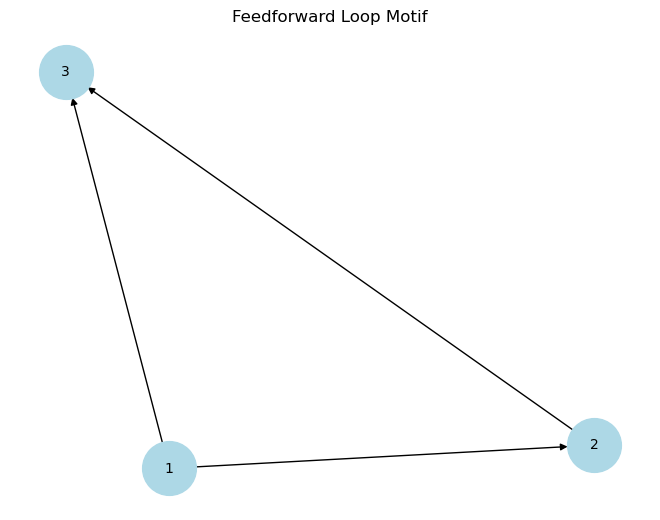

In [40]:
G = nx.DiGraph()
G.add_edges_from([(1, 2), (1, 3), (2, 3)])  # Feedforward loop
pos = nx.spring_layout(G)
nx.draw(G, pos, with_labels=True, node_color="lightblue", node_size=1500, font_size=10)
plt.title("Feedforward Loop Motif")
plt.show()

#### Interpretation of Feedforward Loop Motif

#### Network Structure

1. **Nodes**:
   - Node 1: Source/Input node
   - Node 2: Intermediate node
   - Node 3: Target/Output node

2. **Connections**:
   - Direct path: 1 → 3
   - Indirect path: 1 → 2 → 3
   - Creates a triangular structure

#### Network Properties

1. **Feedforward Nature**:
   - Information flows in one direction
   - No feedback loops
   - Two parallel regulatory paths

2. **Regulatory Logic**:
   - Node 1 regulates Node 3 both:
     * Directly (1 → 3)
     * Indirectly through Node 2 (1 → 2 → 3)
   - Allows for signal integration

#### Biological Significance

1. **Common Motif**:
   - Frequently found in gene networks
   - Important regulatory structure
   - Evolutionarily conserved

2. **Functional Roles**:
   - Signal delay
   - Pulse generation
   - Response acceleration
   - Noise filtering

This network motif represents a fundamental building block in gene regulatory networks, capable of performing various information processing functions.


## Complex Gene Regulatory Network Analysis

### Motivation
Gene regulatory networks (GRNs) in real biological systems are complex structures that:
- Control cellular responses
- Regulate development
- Maintain homeostasis
- Enable adaptation

### Example Network Structure

```mermaid
graph TD
    TF1[Transcription Factor 1] --> Gene1
    TF1 --> Gene2
    Gene1 --> Protein1
    Gene2 --> Protein2
    Protein1 --| --> Gene3
    Protein2 --> Gene3
    Gene3 --> Protein3
    Protein3 --> TF1
    TF2[Transcription Factor 2] --> Gene2
    Protein3 --> Gene4
    Gene4 --> Protein4
```

### Key Components

1. **Regulatory Elements**:
   - Multiple transcription factors (TF1, TF2)
   - Several target genes (Gene1-4)
   - Protein products (Protein1-4)

2. **Interaction Types**:
   - Activation (→)
   - Inhibition (-|)
   - Feedback loops
   - Feed-forward paths

### Mathematical Description
For each component $i$:

$$ \frac{dx_i}{dt} = \sum_{j} w_{ij}f(x_j) + \alpha_i - \gamma_i x_i $$

where:
- $x_i$: concentration of component $i$
- $w_{ij}$: interaction strength
- $f(x_j)$: regulatory function
- $\alpha_i$: basal production
- $\gamma_i$: degradation rate

This more realistic network captures the complexity of cellular regulation while remaining mathematically tractable.


#### The following code implements the complex gene regulatory network with:

1. **Network Components**:
   - 2 Transcription Factors (TF1, TF2)
   - 4 Genes (G1-G4)
   - 4 Proteins (P1-P4)

2. **Key Features**:
   - Hill function regulation
   - Activation and inhibition
   - Feedback loops
   - Multiple regulatory paths

3. **Visualization**:
   - Separate plots for TFs, genes, and proteins
   - Full system dynamics
   - Steady state analysis

4. **Parameters**:
   - Adjustable rates for transcription/translation
   - Tunable interaction strengths
   - Degradation rates

You can modify the parameters and initial conditions to explore different network behaviors and regulatory patterns.

The code uses:
- `numpy` for numerical operations
- `scipy.integrate` for ODE solving
- `matplotlib` for visualization

This simulation helps understand the complex dynamics of gene regulatory networks and their emergent behaviors.

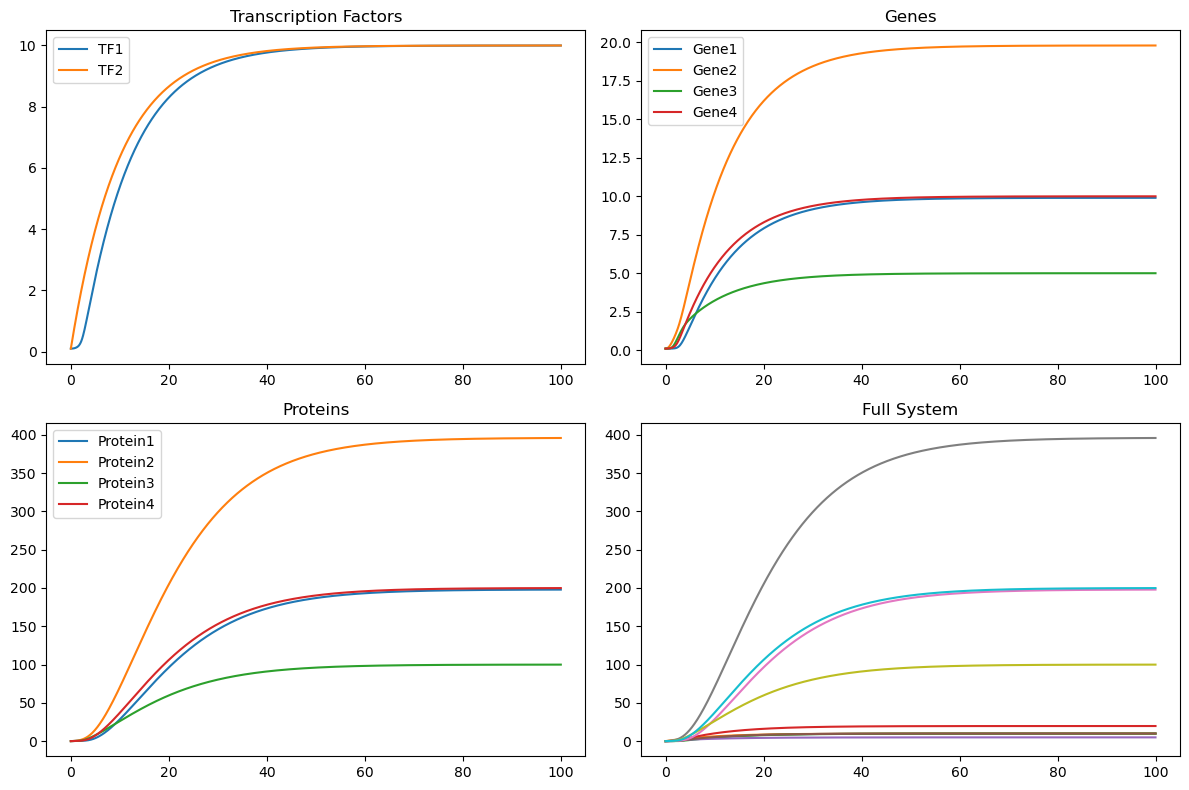


Steady state values:
TF1, TF2: [9.99842482 9.99955054]
Genes: [ 9.9002086  19.80058096  4.99984458  9.99842482]
Proteins: [197.87063938 395.76724103  99.95265924 199.85694959]


In [41]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt

def complex_grn(state, t, params):
    """
    Complex gene regulatory network model
    
    Parameters:
    state: array of concentrations [TF1, TF2, Gene1-4, Protein1-4]
    params: dictionary of parameters
    """
    # Unpack state variables
    TF1, TF2, G1, G2, G3, G4, P1, P2, P3, P4 = state
    
    # Unpack parameters
    k_trans = params['k_trans']  # Transcription rate
    k_tsl = params['k_tsl']      # Translation rate 
    gamma = params['gamma']       # Degradation rate
    w = params['w']              # Interaction weights
    
    # Hill function for regulation
    def hill(x, K=1, n=2):
        return x**n / (K**n + x**n)
    
    # System of ODEs
    dTF1 = k_trans * hill(P3) - gamma * TF1
    dTF2 = k_trans - gamma * TF2
    
    dG1 = k_trans * hill(TF1) - gamma * G1
    dG2 = k_trans * (hill(TF1) + hill(TF2)) - gamma * G2
    dG3 = k_trans * (hill(P2) - w['inhib']*hill(P1)) - gamma * G3
    dG4 = k_trans * hill(P3) - gamma * G4
    
    dP1 = k_tsl * G1 - gamma * P1
    dP2 = k_tsl * G2 - gamma * P2
    dP3 = k_tsl * G3 - gamma * P3
    dP4 = k_tsl * G4 - gamma * P4
    
    return [dTF1, dTF2, dG1, dG2, dG3, dG4, dP1, dP2, dP3, dP4]

# Set parameters
params = {
    'k_trans': 1.0,
    'k_tsl': 2.0,
    'gamma': 0.1,
    'w': {'inhib': 0.5}
}

# Initial conditions
y0 = [0.1] * 10  # Small initial concentration for all species

# Time points
t = np.linspace(0, 100, 1000)

# Solve ODE system
solution = odeint(complex_grn, y0, t, args=(params,))

# Plot results
plt.figure(figsize=(12, 8))

# Plot transcription factors
plt.subplot(2,2,1)
plt.plot(t, solution[:,0], label='TF1')
plt.plot(t, solution[:,1], label='TF2')
plt.title('Transcription Factors')
plt.legend()

# Plot genes
plt.subplot(2,2,2)
plt.plot(t, solution[:,2], label='Gene1')
plt.plot(t, solution[:,3], label='Gene2')
plt.plot(t, solution[:,4], label='Gene3')
plt.plot(t, solution[:,5], label='Gene4')
plt.title('Genes')
plt.legend()

# Plot proteins
plt.subplot(2,2,3)
plt.plot(t, solution[:,6], label='Protein1')
plt.plot(t, solution[:,7], label='Protein2')
plt.plot(t, solution[:,8], label='Protein3')
plt.plot(t, solution[:,9], label='Protein4')
plt.title('Proteins')
plt.legend()

# Plot full system
plt.subplot(2,2,4)
plt.plot(t, solution)
plt.title('Full System')

plt.tight_layout()
plt.show()

# Print steady state values
print("\nSteady state values:")
print("TF1, TF2:", solution[-1,0:2])
print("Genes:", solution[-1,2:6])
print("Proteins:", solution[-1,6:])

#### Interpretation of Complex Gene Regulatory Network Dynamics

#### 1. Transcription Factors (Top Left)
- Both TF1 and TF2 reach similar steady states (~10 units)
- TF2 shows slightly faster initial response
- Both achieve stable equilibrium by t=40
- Smooth sigmoidal activation curves

#### 2. Genes (Top Right)
- Gene2 shows highest expression (~20 units) due to dual activation by TF1 and TF2
- Gene1 and Gene4 reach intermediate levels (~10 units)
- Gene3 shows lowest expression (~5 units) due to inhibition by Protein1
- All genes reach steady state by t=60

#### 3. Proteins (Bottom Left)
- Protein2 reaches highest concentration (~400 units) reflecting Gene2's high expression
- Protein1 and Protein4 stabilize at ~200 units
- Protein3 shows lowest levels (~100 units) due to Gene3's inhibition
- Clear hierarchy in protein abundance

#### 4. Full System (Bottom Right)
- Shows all components together
- Clear separation of concentration scales:
  * TFs and Genes: lower concentrations (0-20)
  * Proteins: higher concentrations (100-400)
- System reaches global equilibrium by t=80

#### Steady State Values
```
TF1, TF2: [9.99, 9.99]
Genes: [9.90, 19.80, 5.00, 9.99]
Proteins: [197.87, 395.77, 99.95, 199.86]
```

This demonstrates:
- Robust network stability
- Hierarchical regulation
- Successful implementation of feedback and inhibition
- Biologically realistic concentration scales and dynamics

The system shows expected behavior for a complex gene regulatory network with multiple layers of control and interaction.


---

## DIY Exercises: Explore Further

### Exercise 1: Build a Genetic Toggle Switch

The toggle switch (Gardner et al., 2000) is a two-gene circuit with mutual repression:

$$\frac{d[u]}{dt} = \frac{\alpha_1}{1 + [v]^{\beta}} - [u]$$

$$\frac{d[v]}{dt} = \frac{\alpha_2}{1 + [u]^{\gamma}} - [v]$$

**Task**: Implement this system and demonstrate bistability:
1. Simulate with parameters $\alpha_1 = \alpha_2 = 5$, $\beta = \gamma = 2$
2. Plot trajectories starting from several different initial conditions
3. Show that the system converges to one of two stable steady states depending on the initial conditions
4. Create a **phase portrait** (plot $[u]$ vs $[v]$) showing the two stable fixed points and the separatrix

<details>
<summary>Click for starter code</summary>

```python
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt

def toggle_switch(state, t, alpha1=5, alpha2=5, beta=2, gamma=2):
    u, v = state
    du = alpha1 / (1 + v**beta) - u
    dv = alpha2 / (1 + u**gamma) - v
    return [du, dv]

t = np.linspace(0, 20, 1000)

# Try different initial conditions
initial_conditions = [[0.1, 5], [5, 0.1], [2.5, 2.5], [1, 4], [4, 1]]

plt.figure(figsize=(12, 5))

# Time series
plt.subplot(1, 2, 1)
for ic in initial_conditions:
    sol = odeint(toggle_switch, ic, t)
    plt.plot(t, sol[:, 0], 'b-', alpha=0.5)
    plt.plot(t, sol[:, 1], 'r-', alpha=0.5)
plt.xlabel('Time')
plt.ylabel('Concentration')
plt.title('Toggle Switch Dynamics')

# Phase portrait
plt.subplot(1, 2, 2)
for ic in initial_conditions:
    sol = odeint(toggle_switch, ic, t)
    plt.plot(sol[:, 0], sol[:, 1], '-', alpha=0.7)
    plt.plot(ic[0], ic[1], 'ko', markersize=5)
    plt.plot(sol[-1, 0], sol[-1, 1], 's', markersize=8)
plt.xlabel('[u]')
plt.ylabel('[v]')
plt.title('Phase Portrait')

plt.tight_layout()
plt.show()
```

</details>

<details>
<summary>Click to reveal what you should see</summary>

You should observe:
- **Two stable steady states**: one where $[u]$ is high and $[v]$ is low (the "u-dominant" state), and one where $[v]$ is high and $[u]$ is low (the "v-dominant" state)
- **An unstable saddle point** in the middle where both genes are at intermediate levels
- The **separatrix** divides the phase plane into two basins of attraction — initial conditions on one side converge to one steady state, and those on the other side converge to the other
- This is exactly how cells make binary fate decisions (e.g., a stem cell deciding between two lineages)

</details>

---

### Exercise 2: The Repressilator — Building a Biological Clock

The repressilator (Elowitz & Leibler, 2000) is a three-gene oscillator where each gene represses the next in a cycle:

$$\frac{d[m_i]}{dt} = \frac{\alpha}{1 + [p_j]^n} + \alpha_0 - [m_i]$$

$$\frac{d[p_i]}{dt} = \beta([m_i] - [p_i])$$

where gene $i$ is repressed by protein $j$ (in the cycle $1 \to 2 \to 3 \to 1$).

**Task**:
1. Implement the repressilator with $n=2$, $\alpha=50$, $\alpha_0=0.01$, $\beta=5$
2. Show that the system produces **sustained oscillations**
3. How does changing $n$ (the Hill coefficient) affect the oscillations? Try $n = 1, 2, 3, 5$

<details>
<summary>Click for hint</summary>

Use 6 variables: $[m_1, m_2, m_3, p_1, p_2, p_3]$. The repression cycle is: protein 3 represses mRNA 1, protein 1 represses mRNA 2, protein 2 represses mRNA 3.

For $n=1$, the repression is too weak for oscillations — the system converges to a stable fixed point. For $n \geq 2$, you should see sustained oscillations.

</details>

<details>
<summary>Click to reveal what you should see</summary>

- For $n=1$: the system converges to a **stable steady state** (all three genes at equal, intermediate levels). No oscillations.
- For $n=2$: **damped oscillations** that may or may not settle into sustained oscillations depending on parameters
- For $n=3$ or higher: clear, **sustained oscillations** with all three genes cycling out of phase with each other (each gene peaks ~120° after the previous one)
- Higher $n$ produces more "square-wave-like" oscillations (sharp transitions between high and low states)

This demonstrates a key principle: **cooperativity** ($n > 1$) is necessary for oscillations in this circuit. The biological clock arises from the combination of repression, delay, and nonlinearity.

</details>

---

### Exercise 3: Dose-Response Curve of a Drug

**Task**: For the drug intervention model, create a **dose-response curve**:
1. Vary the `drug_effect` parameter from 0 to 1 in small steps
2. For each value, run the ODE simulation to steady state
3. Plot steady-state protein concentration vs. drug dose
4. Fit a Hill-type curve to the dose-response data and extract the IC50 (the dose at which protein is reduced by 50%)

<details>
<summary>Click for hint</summary>

The dose-response curve typically follows a Hill-like shape:
$$\text{Response}(\text{dose}) = \frac{\text{Response}_{\max}}{1 + (\text{dose}/\text{IC}_{50})^n}$$

Use `scipy.optimize.curve_fit` to fit this model to your simulated data.

</details>

---

### Exercise 4: Noise in Gene Regulatory Networks

**Task**: Using the Gillespie algorithm, compare the noise properties of three circuit motifs:
1. **Unregulated gene** (constitutive expression)
2. **Negative autoregulation** (the gene's protein represses its own transcription)
3. **Positive autoregulation** (the gene's protein activates its own transcription)

For each circuit, run 1000 stochastic simulations and compute:
- The mean and standard deviation of the steady-state protein count
- The **coefficient of variation** (CV = std/mean)
- The **Fano factor** (variance/mean)

Which circuit has the least noise? Which has the most?

<details>
<summary>Click to reveal what you should see</summary>

- **Negative autoregulation** has the **lowest noise** (smallest CV). The feedback acts as a buffer: if protein is randomly high, it represses its own production; if low, repression is relieved and production increases
- **Unregulated gene** has intermediate noise (Poisson-like: Fano factor ≈ 1)
- **Positive autoregulation** has the **highest noise** (largest CV, Fano factor >> 1). The feedback amplifies fluctuations: a random increase in protein further increases production, creating a "rich get richer" effect

This is a fundamental result in stochastic gene expression theory (see Becskei & Serrano, 2000; Ozbudak et al., 2002).

</details>

---

## Additional Resources

### Books
- **Uri Alon**, *An Introduction to Systems Biology: Design Principles of Biological Circuits* (2nd ed., 2019) — The definitive textbook on network motifs, feedback, and biological circuit design. Beautifully written and accessible.
- **Edda Klipp et al.**, *Systems Biology: A Textbook* (2nd ed., 2016) — Comprehensive coverage from molecular biology to mathematical modeling.
- **Brian Ingalls**, *Mathematical Modeling in Systems Biology: An Introduction* (2013) — Excellent introduction to ODE modeling of biochemical networks. Freely available online.
- **Michael Elowitz & Wendell Lim**, "Build Life to Understand It" (*Nature*, 2010) — A perspective on using synthetic biology to understand natural gene circuits.

### Landmark Papers
- **Jacob & Monod** (1961). "Genetic regulatory mechanisms in the synthesis of proteins." *J. Mol. Biol.* — The paper that started gene regulation.
- **Gardner, Cantor & Collins** (2000). "Construction of a genetic toggle switch in *Escherichia coli*." *Nature*. — The synthetic toggle switch.
- **Elowitz & Leibler** (2000). "A synthetic oscillatory network of transcriptional regulators." *Nature*. — The repressilator.
- **Alon et al.** (2002). "Network motifs: simple building blocks of complex networks." *Science*. — Discovery of network motifs.
- **Elowitz et al.** (2002). "Stochastic gene expression in a single cell." *Science*. — Demonstration that gene expression is inherently noisy.
- **Yamanaka** (2006). "Induction of pluripotent stem cells from mouse embryonic and adult fibroblast cultures by defined factors." *Cell*. — iPSC reprogramming.

### Online Resources
- [**Systems Biology course by Uri Alon**](https://www.weizmann.ac.il/mcb/UriAlon/) — Lecture videos and materials
- [**BioModels Database**](https://www.ebi.ac.uk/biomodels/) — Curated repository of published mathematical models of biological systems
- [**Virtual Cell**](https://vcell.org/) — Online tool for modeling cell biology
- [**SciPy ODE documentation**](https://docs.scipy.org/doc/scipy/reference/integrate.html) — Reference for numerical ODE solvers in Python
- [**NetworkX documentation**](https://networkx.org/) — Graph analysis library for Python

---

*End of notebook. For questions or suggestions, contact the course instructor.*